# 🏦 Bank Customer Segmentation

**Goal:** Use Unsupervised Machine Learning to segment bank customers into distinct financial profiles, helping the business make data-driven marketing decisions.

**Main Steps:**
1. **Data Exploration:** Analyze customer demographics and financial behaviors.
2. **Distance Metric:** Use **Gower Distance** with custom weights to correctly handle mixed data types (numerical + categorical).
3. **Clustering:** Use **K-Medoids** as the main model to build balanced segments, alongside Hierarchical Clustering for initial exploration.
4. **Visualization:** Apply **t-SNE** and **PCA** to visualize the high-dimensional data in 2D.
5. **Business Insights:** Translate the final clusters into actionable customer personas.

In [222]:
# Imports

# For the first time, you may need to install the following libraries:
# %pip install plotly
# %pip install plotly nbformat

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from kmedoids import KMedoids
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score, silhouette_samples
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)

import gower

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

import plotly.graph_objects as go
import plotly.express as px

from scipy.stats import kruskal, chi2_contingency

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 1. Load & Inspect the Data

In [223]:
# Load data
df = pd.read_excel('Dataset1_BankClients.xlsx')
metadata = pd.read_excel('BankClients_Metadata.xlsx')

# Drop ID — not informative for clustering
df = df.drop(columns=['ID'])

print(f'Dataset shape: {df.shape}  ({df.shape[0]} clients, {df.shape[1]} features)')
print(f'\nMissing values:\n{df.isnull().sum()}')

Dataset shape: (5000, 17)  (5000 clients, 17 features)

Missing values:
Age            0
Gender         0
Job            0
Area           0
CitySize       0
FamilySize     0
Income         0
Wealth         0
Debt           0
FinEdu         0
ESG            0
Digital        0
BankFriend     0
LifeStyle      0
Luxury         0
Saving         0
Investments    0
dtype: int64


In [224]:
# Quick data inspection
print('--- First 5 Rows of the Dataset ---')
display(df.head())

print('\n--- Descriptive Statistics (Mean, Min, Max) ---')
display(df.describe().round(2))

--- First 5 Rows of the Dataset ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2



--- Descriptive Statistics (Mean, Min, Max) ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,60.45,0.53,2.46,1.38,1.93,2.49,0.58,0.58,0.43,0.51,0.59,0.53,0.62,0.46,0.47,0.52,2.18
std,21.82,0.50,1.25,0.68,0.76,1.41,0.21,0.21,0.22,0.19,0.17,0.21,0.16,0.22,0.24,0.19,0.82
min,19.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.04,0.00,0.12,0.00,0.00,0.00,1.00
25%,42.00,0.00,2.00,1.00,1.00,1.00,0.41,0.42,0.26,0.37,0.47,0.37,0.51,0.28,0.27,0.40,1.00
50%,61.00,1.00,2.00,1.00,2.00,2.00,0.58,0.59,0.45,0.50,0.60,0.52,0.63,0.45,0.46,0.54,2.00
75%,80.00,1.00,2.00,2.00,3.00,3.00,0.75,0.75,0.60,0.65,0.71,0.70,0.75,0.64,0.66,0.66,3.00
max,95.00,1.00,5.00,3.00,3.00,6.00,0.98,1.00,0.98,0.96,0.99,0.97,0.97,0.99,1.00,0.97,3.00


## 2. Exploratory Data Analysis (EDA)

Before diving into the clustering model, we conduct a thorough diagnostic of the dataset to ensure our segmentation is built on significant behavioral markers. This phase focuses on mapping the distributions of financial variables and investigating the correlations between client demographics and investment behaviors.

To understand the overall structure of the data, we focus on:

**Distribution of numerical variables** — to analyze skewness, concentration, and the spread of financial attributes.

**Correlation matrix** — to identify redundant features and detect natural groupings between variables.

**Demographic Intersections** — to verify how traits like Age or Job influence the bank-client relationship.

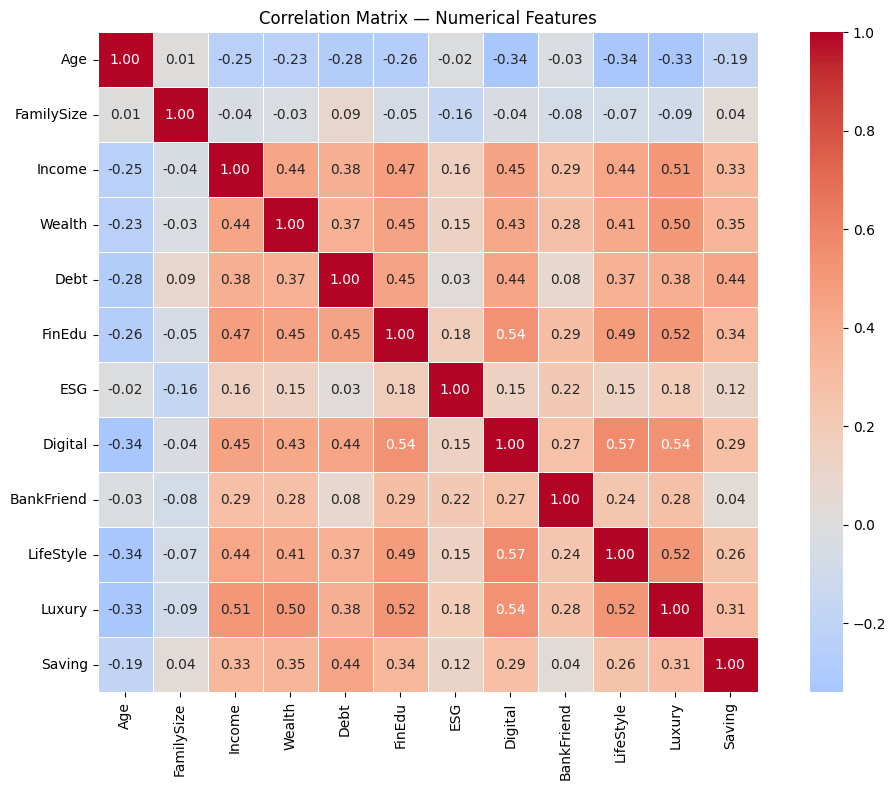

In [225]:
# Correlation heatmap (numerical features only)
numerical_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt',
                  'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']

plt.figure(figsize=(11, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

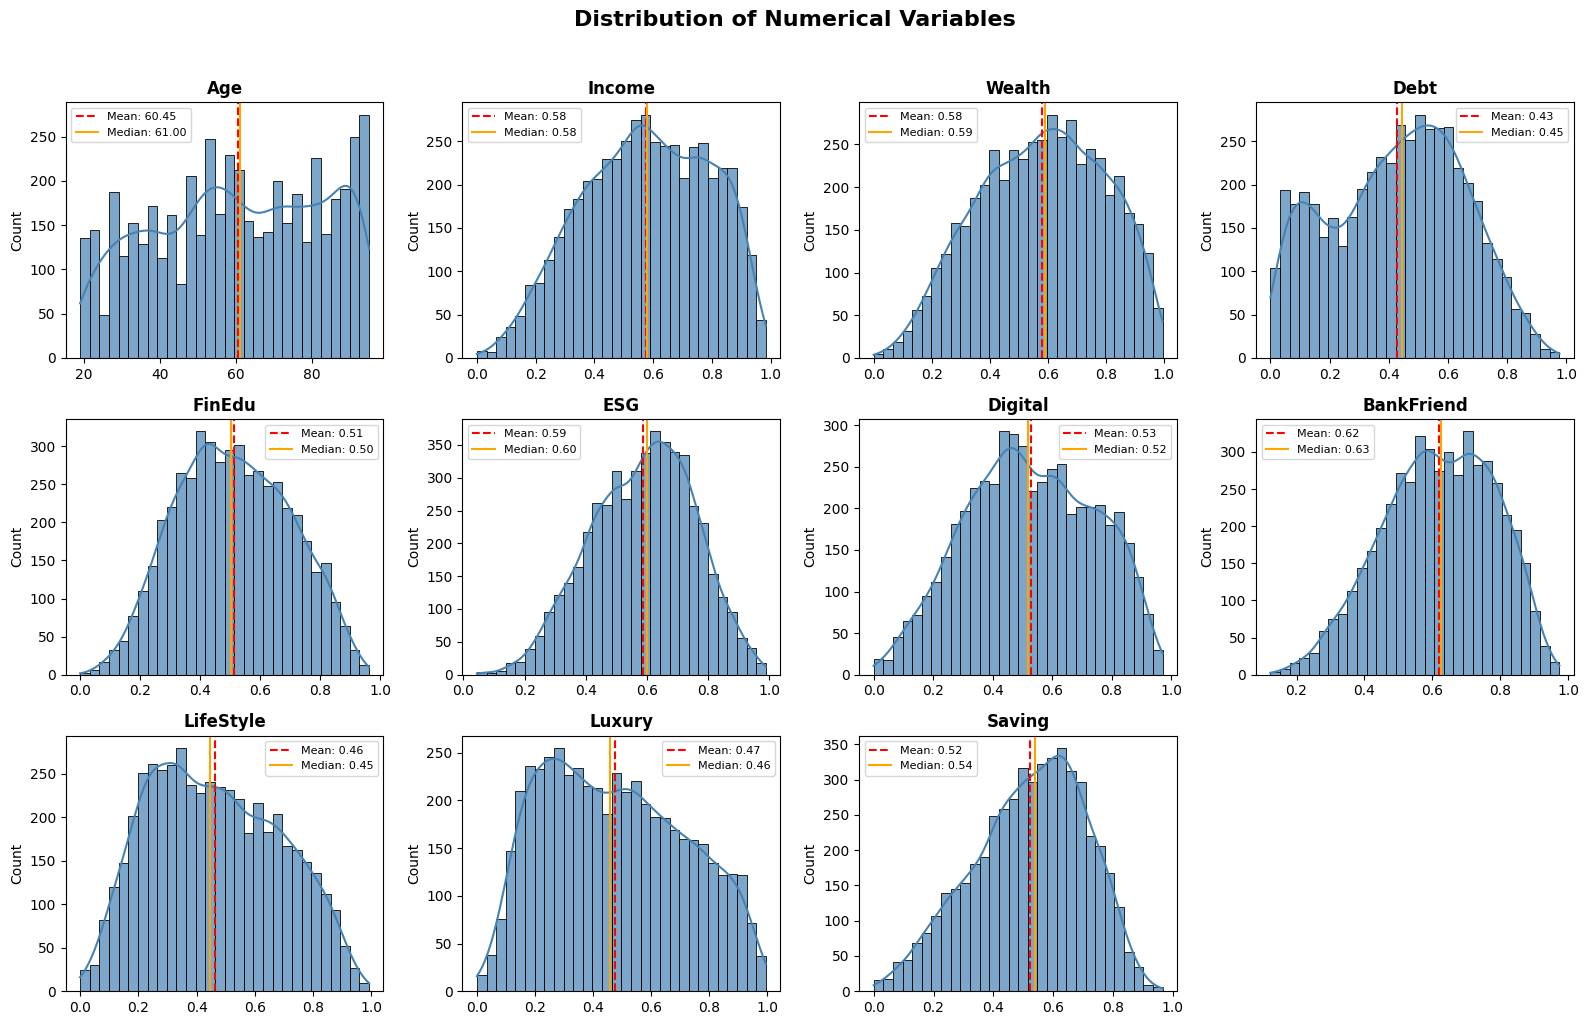

--- Summary Statistics for Numerical Variables ---


,Age,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving
mean,60.45,0.576,0.579,0.429,0.511,0.587,0.528,0.619,0.462,0.475,0.521
median,61.0,0.58,0.589,0.446,0.504,0.599,0.519,0.625,0.446,0.458,0.539
std,21.822,0.213,0.215,0.224,0.187,0.168,0.214,0.163,0.221,0.24,0.186
skew,-0.134,-0.194,-0.164,-0.093,0.056,-0.197,-0.064,-0.255,0.191,0.224,-0.347
skew_interpretation,symmetric,symmetric,symmetric,symmetric,symmetric,symmetric,symmetric,symmetric,symmetric,symmetric,symmetric


In [226]:
numerical_cols = ['Age', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 
                  'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']
 
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
 
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='steelblue', alpha=0.7)
 
    # Mean and median reference lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')
 
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
 
axes[11].axis('off')
 
plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 
# Summary statistics table
print('--- Summary Statistics for Numerical Variables ---')
summary_stats = df[numerical_cols].agg(['mean', 'median', 'std', 'skew']).round(3)
summary_stats.loc['skew_interpretation'] = summary_stats.loc['skew'].apply(
    lambda x: 'symmetric' if abs(x) < 0.5 else ('right-skewed' if x > 0 else 'left-skewed')
)
display(summary_stats)

**Interpretation — Variable Distributions:**
 
- **Age**: Roughly uniform with a slight right skew toward older clients (mean ~60 years). This is typical of bank clients — younger people have fewer financial products.
- **Income & Wealth**: Both are approximately normal/symmetric around 0.58, indicating a well-balanced sample across wealth levels after normalization.
- **Debt**: Left-skewed (mean 0.43) — most clients have low-to-moderate debt, with fewer high-debt outliers.
- **FinEdu, ESG, Digital**: Centered around 0.5-0.6, roughly symmetric. These behavioral scores don't show extreme concentration.
- **BankFriend**: Slightly right-skewed with a higher mean (0.62) — clients generally report positive bank relationships.
- **LifeStyle & Luxury**: Both centered around 0.45-0.47, symmetric — lifestyle indicators are evenly distributed.
- **Saving**: Symmetric around 0.52 — no strong skew in saving propensity.
 
*Takeaway*: The normalized variables are well-behaved (no extreme skewness), which is good for clustering algorithms. Age is the only non-normalized variable and shows the expected older-skewed distribution of bank clients.

### 2.1 Gender vs Investment Behavior — Independence Test



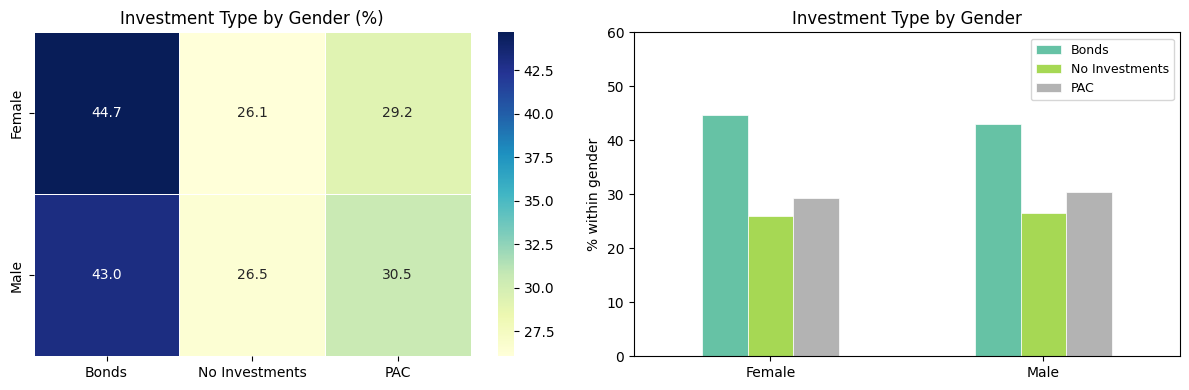


Chi-square test: chi2=1.53, p=4.64e-01
→ Nessuna differenza significativa


In [227]:
# Gender vs Investments — independent from clustering, uses a temporary copy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Label mappings (verify that numeric codes match your dataset)
gen_map = {0: 'Female', 1: 'Male'} 
inv_map = {1: 'No Investments', 2: 'Lump Sum', 3: 'Capital Acc. (PAC)'}

df_plot = df.copy()

# Apply mappings on the temporary dataframe only
df_plot['Gen_L'] = df_plot['Gender'].map(gen_map)
df_plot['Inv_L'] = df_plot['Investments'].map(inv_map)

# Cross-tabulation (row-normalized)
gen_inv = pd.crosstab(df_plot['Gen_L'], df_plot['Inv_L'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap
sns.heatmap(gen_inv, annot=True, fmt='.1f', cmap='YlGnBu',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Investment Type by Gender (%)')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Bar chart
gen_inv.plot(kind='bar', ax=axes[1], colormap='Set2',
             edgecolor='white', linewidth=0.5)
axes[1].set_title('Investment Type by Gender')
axes[1].set_xlabel('')
axes[1].set_ylabel('% within gender')
axes[1].set_ylim(0, 60)
axes[1].set_xticklabels(gen_inv.index, rotation=0)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Chi-square test on raw frequencies
ct_raw = pd.crosstab(df_plot['Gen_L'], df_plot['Inv_L'])
chi2, p, dof, _ = chi2_contingency(ct_raw)
print(f'\nChi-square test: chi2={chi2:.2f}, p={p:.2e}')
print('→ Statistically significant difference' if p < 0.05 else '→ No significant difference')

Direct cross-tabulation shows males and females invest in PAC at nearly identical
rates (44.7% vs 43.0%). Chi-square test confirms no significant association
between gender and investment type (chi2=1.53, p=0.46).

Since gender does not predict investment behavior in the full population,
it will not be crucial for clustering.

### 2.2 Geographic Patterns: Area vs Financial Variables

We investigate whether the geographic area (Nord, Centro, Sud/Isole) is associated with differences in wealth, income, job composition, and debt levels.


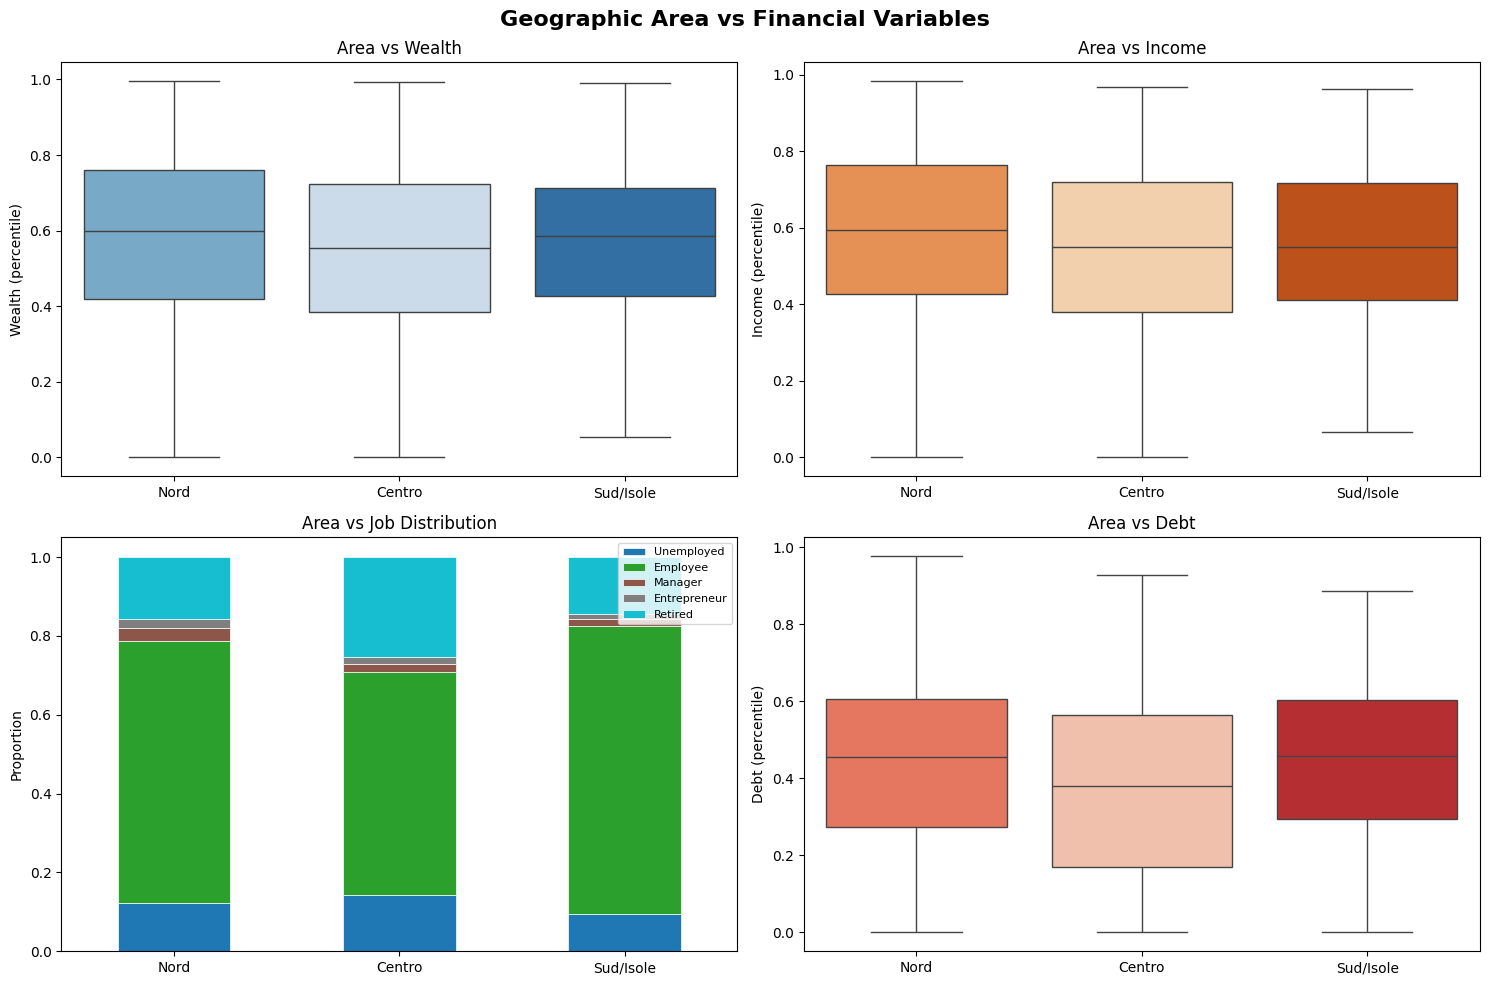

In [228]:
# Area vs Wealth, Income, Job, Debt
area_map = {1: 'Nord', 2: 'Centro', 3: 'Sud/Isole'}
job_map  = {1: 'Unemployed', 2: 'Employee', 3: 'Manager', 4: 'Entrepreneur', 5: 'Retired'}
df['Area_L'] = df['Area'].map(area_map)
df['Job_L']  = df['Job'].map(job_map)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Geographic Area vs Financial Variables', fontsize=16, fontweight='bold')

# Area vs Wealth
sns.boxplot(data=df, x='Area_L', y='Wealth', hue='Area_L', ax=axes[0,0],
            palette='Blues', order=['Nord','Centro','Sud/Isole'], legend=False)
axes[0,0].set_title('Area vs Wealth')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Wealth (percentile)')

# Area vs Income
sns.boxplot(data=df, x='Area_L', y='Income', hue='Area_L', ax=axes[0,1],
            palette='Oranges', order=['Nord','Centro','Sud/Isole'], legend=False)
axes[0,1].set_title('Area vs Income')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Income (percentile)')

# Area vs Job — stacked bar
job_area_ct = pd.crosstab(df['Area_L'], df['Job_L'], normalize='index')
job_area_ct = job_area_ct[['Unemployed','Employee','Manager','Entrepreneur','Retired']]
job_area_ct.loc[['Nord','Centro','Sud/Isole']].plot(
    kind='bar', stacked=True, ax=axes[1,0], colormap='tab10', edgecolor='white',
    linewidth=0.5)
axes[1,0].set_title('Area vs Job Distribution')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Proportion')
axes[1,0].legend(fontsize=8, loc='upper right')
axes[1,0].tick_params(axis='x', rotation=0)

# Area vs Debt
sns.boxplot(data=df, x='Area_L', y='Debt', hue='Area_L', ax=axes[1,1],
            palette='Reds', order=['Nord','Centro','Sud/Isole'], legend=False)
axes[1,1].set_title('Area vs Debt')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Debt (percentile)')

plt.tight_layout()
plt.show()

**Interpretation — Area vs Financial Variables:**

- **Income and Wealth** show mild geographic disparities: Nord has slightly higher medians. This reflects Italian macro-economic structure but the differences are modest — geographic area alone is a poor predictor of financial status.
- **Job composition** varies: Sud/Isole has a larger share of retired clients and relatively more employees, while Nord has more diverse job profiles. This is consistent with the age structure and labor market differences across Italian regions.
- **Debt** is surprisingly uniform across regions — the median and interquartile range are similar everywhere. This suggests that debt levels are more driven by personal/family factors than by geography.

*Important for clustering*: Area alone won't be a strong cluster driver, but it adds complementary information when combined with other features.

### 2.3 Investment Behavior: Investments vs Financial Education & Digital Propensity

Are clients who invest (especially in capital accumulation plans) more financially educated and more digitally active? This relationship is central to understanding the drivers of investment behavior.


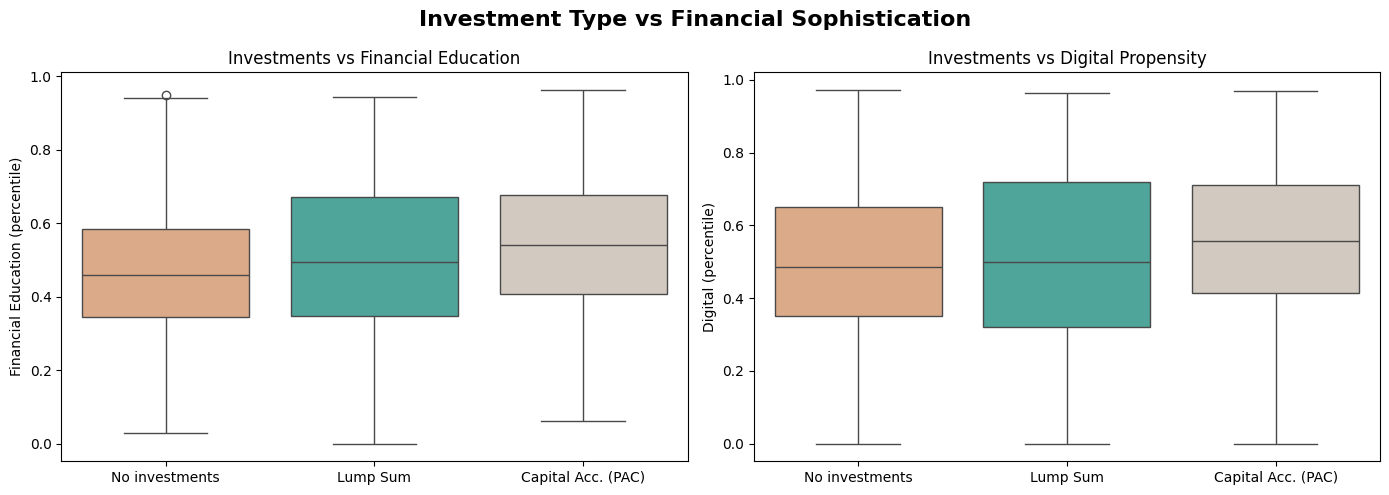

In [229]:
# Investments vs FinEdu and Digital
inv_map = {1: 'No investments', 2: 'Lump Sum', 3: 'Capital Acc. (PAC)'}
df['Inv_L'] = df['Investments'].map(inv_map)
inv_order = ['No investments', 'Lump Sum', 'Capital Acc. (PAC)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Investment Type vs Financial Sophistication', fontsize=16, fontweight='bold')

# Investments vs FinEdu
sns.boxplot(data=df, x='Inv_L', y='FinEdu', hue='Inv_L', ax=axes[0],
               palette=['#E8A87C','#D5CABD','#41B3A3'], order=inv_order)
axes[0].set_title('Investments vs Financial Education')
axes[0].set_xlabel('')
axes[0].set_ylabel('Financial Education (percentile)')

# Investments vs Digital
sns.boxplot(data=df, x='Inv_L', y='Digital', hue='Inv_L', ax=axes[1],
               palette=['#E8A87C','#D5CABD','#41B3A3'], order=inv_order)
axes[1].set_title('Investments vs Digital Propensity')
axes[1].set_xlabel('')
axes[1].set_ylabel('Digital (percentile)')

plt.tight_layout()
plt.show()

**Interpretation — Investments vs FinEdu & Digital:**

There is a clear monotonic gradient: clients investing in PAC (capital accumulation) plans have the highest financial education (0.538 vs 0.469 for non-investors) and digital propensity (0.555 vs 0.500). 

PAC plans require understanding of long-term investment horizons, and often digital platforms to manage regular payments. Lump-sum investors sit in between — they have enough financial knowledge to invest, but perhaps prefer a simpler, one-time approach.

*Important for clustering*: Financial education and digital propensity are key drivers (or at least strong correlates) of investment sophistication. These variables will likely differentiate clusters.


### 2.4 Investment Behavior: Investments vs Age & Job

Do older or retired clients prefer different investment types? Does professional status influence investment choice?

**Important**: the heatmap is now normalized **by Job** (column-wise), so we read it as: *"Of all Managers, what % invests in PAC?"*. This is much more informative than normalizing by investment type, because job categories have very unequal sizes (3,284 employees vs only 107 entrepreneurs).


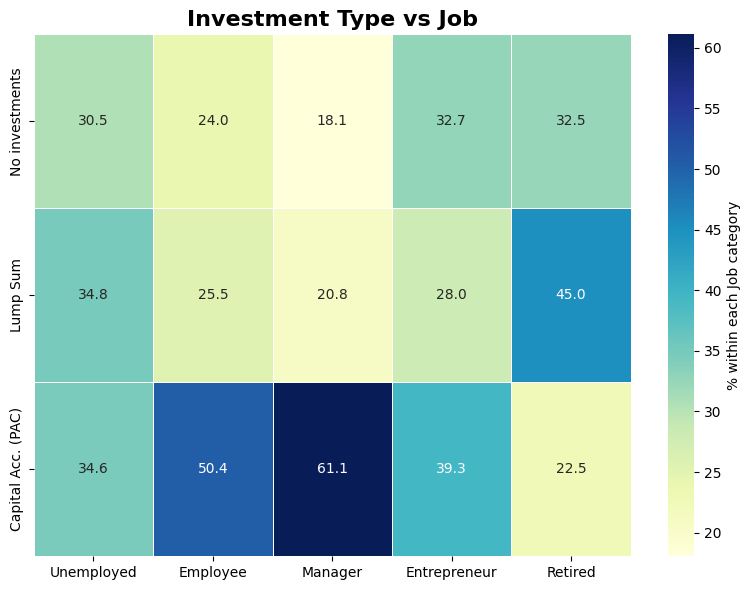

In [230]:
# Investments vs Job — heatmap normalized by Job (column-wise)
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Investment Type vs Job', fontsize=16, fontweight='bold')

# Reads: "Of all people with Job=X, what % invests in each type?"
inv_job_ct = pd.crosstab(df['Inv_L'], df['Job_L'], normalize='columns') * 100
job_order = ['Unemployed','Employee','Manager','Entrepreneur','Retired']

# Ensure inv_order is defined before this step
inv_job_ct = inv_job_ct.loc[inv_order, job_order]

sns.heatmap(inv_job_ct, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% within each Job category'})
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Heatmap (normalized by Job column)**: The heatmap now answers: *"Of all Managers, what percentage invests in PAC?"*
- **Managers** are the most investment-active: 61.1% use PAC plans — the highest rate of any profession. Only 18.1% don't invest.
- **Employees** are also PAC-oriented (50.4%), consistent with their salary-based income being suitable for regular monthly contributions.
- **Retired** clients overwhelmingly prefer Lump Sum (45%) — they have accumulated savings and invest them in bulk. Only 22.5% use PAC.
- **Unemployed and Entrepreneurs** show higher rates of non-investment (~31-33%), likely due to income instability.

*Important for clustering*: Investment type is a strong signal for both age and profession. The clustering should naturally separate active PAC investors (younger, employed/managers) from conservative lump-sum investors (older, retired).

### 2.5 Investment Behavior: Investments vs Wealth & Saving Propensity

We plot the three investment types in **separate panels** in the Wealth-Saving space. 


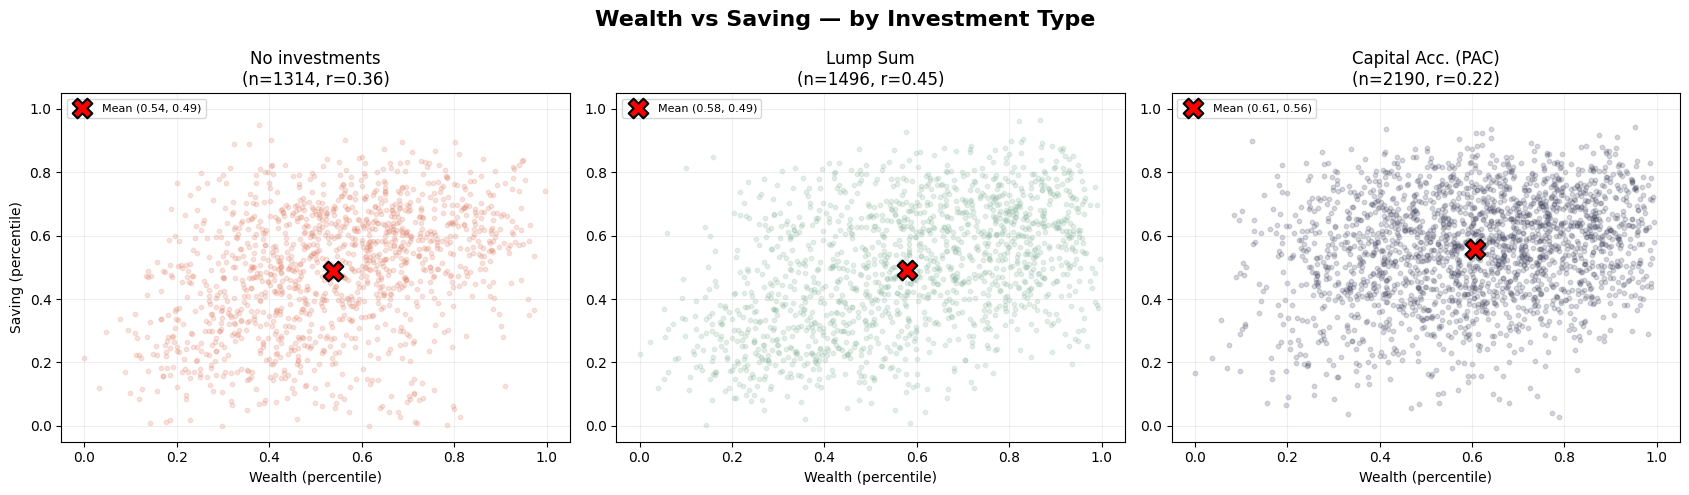

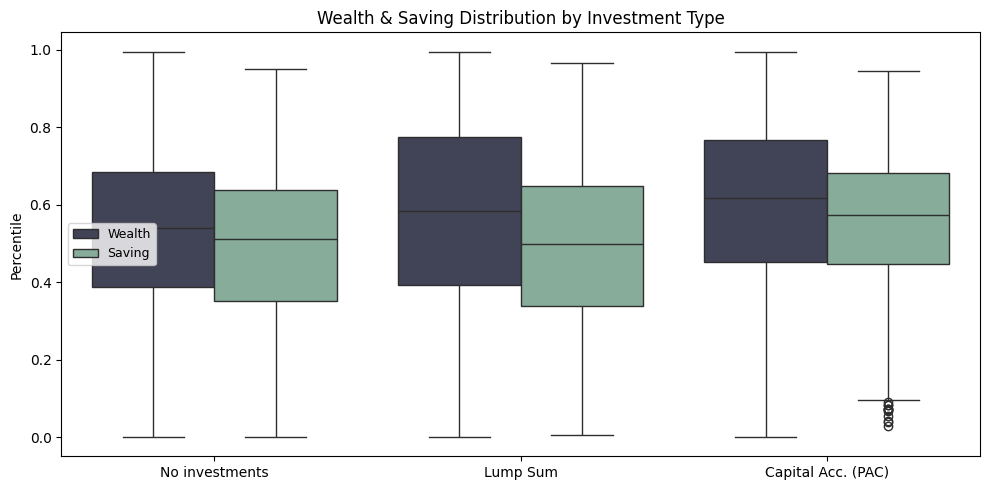

In [231]:
# Investments vs Wealth and Saving — separate panels
inv_colors = {'No investments': '#E07A5F', 'Lump Sum': '#81B29A', 'Capital Acc. (PAC)': '#3D405B'}
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Wealth vs Saving — by Investment Type', fontsize=16, fontweight='bold')
for idx, inv_type in enumerate(inv_order):
    mask = df['Inv_L'] == inv_type
    sub = df[mask]
    axes[idx].scatter(sub['Wealth'], sub['Saving'],
                      alpha=0.2, s=10, color=inv_colors[inv_type])
    axes[idx].set_xlabel('Wealth (percentile)')
    axes[idx].set_ylabel('Saving (percentile)' if idx == 0 else '')
    axes[idx].set_title(f'{inv_type}\n(n={mask.sum()}, r={sub["Wealth"].corr(sub["Saving"]):.2f})')
    axes[idx].set_xlim(-0.05, 1.05)
    axes[idx].set_ylim(-0.05, 1.05)
    axes[idx].grid(True, alpha=0.2)
    axes[idx].scatter(sub['Wealth'].mean(), sub['Saving'].mean(),
                      s=200, marker='X', color='red', edgecolors='black',
                      linewidths=1.5, zorder=5,
                      label=f'Mean ({sub["Wealth"].mean():.2f}, {sub["Saving"].mean():.2f})')
    axes[idx].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

# Boxplot: Wealth and Saving by Investment type
df_melted = df[['Inv_L', 'Wealth', 'Saving']].melt(
    id_vars='Inv_L', var_name='Variable', value_name='Value')

fig2, ax2 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_melted, x='Inv_L', y='Value', hue='Variable',
            ax=ax2, palette=['#3D405B', '#81B29A'], order=inv_order)
ax2.set_title('Wealth & Saving Distribution by Investment Type')
ax2.set_xlabel('')
ax2.set_ylabel('Percentile')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation — Wealth vs Saving by Investment Type (separate panels):**

Splitting into three panels reveals what was hidden in the overlapping scatter:

- **No investments** (left): the cloud is centered lower-left (mean Wealth=0.54, Saving=0.49), with a moderate positive Wealth-Saving correlation (r=0.36). These clients save and earn less — > they are the least financially active segment.
- **Lump Sum** (center): the cloud shifts upward and rightward (mean Wealth=0.58, Saving=0.49), with the strongest correlation (r=0.45). The stronger correlation suggests that lump-sum investors are more 'rational' —> their saving and wealth move together. However, Saving is similar to non-investors: lump-sum investors are wealthier but not necessarily bigger savers.
- **Capital Acc. (PAC)** (right): highest mean on both axes (Wealth=0.61, Saving=0.56), but the **weakest** correlation (r=0.22). This is the key insight — PAC investors save more **regardless of their wealth level**. The weaker correlation means even PAC clients with moderate wealth tend to save actively, which makes sense: PAC is designed for systematic accumulation, attracting disciplined savers at every income level.

*Important for clustering*: PAC investors save more at every wealth level; lump-sum investors are wealthier but not better savers; non-investors are behind on both dimensions.

### 2.6 Family Dynamics: FamilySize vs Debt & Saving

Larger families might carry more debt — but do they save less? The data tells a more nuanced story.


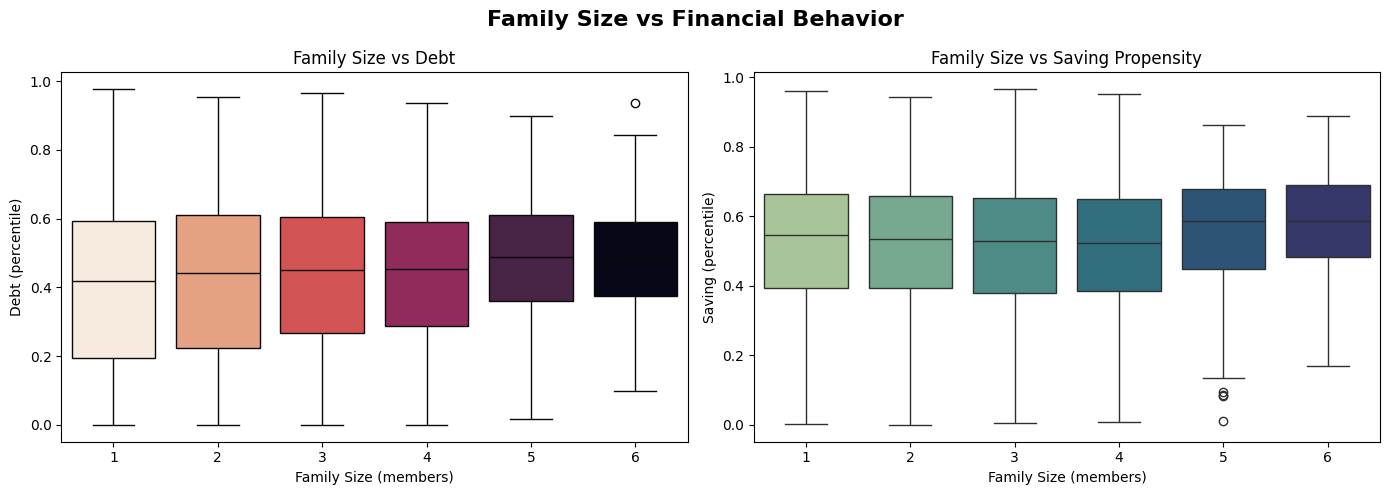

--- Financial profile by Family Size ---
            n_clients  avg_income  avg_debt  avg_saving  pct_pac
FamilySize                                                      
1                1607       0.593     0.407       0.521   42.502
2                1203       0.569     0.428       0.519   41.064
3                 996       0.563     0.436       0.511   45.683
4                 726       0.574     0.437       0.510   43.802
5                 271       0.564     0.481       0.558   47.232
6                 197       0.563     0.490       0.579   56.853


In [232]:
# FamilySize vs Debt and Saving
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Family Size vs Financial Behavior', fontsize=16, fontweight='bold')

# FamilySize vs Debt
sns.boxplot(data=df, x='FamilySize', y='Debt', hue='FamilySize', ax=axes[0],
            palette='rocket_r', legend=False)
axes[0].set_title('Family Size vs Debt')
axes[0].set_xlabel('Family Size (members)')
axes[0].set_ylabel('Debt (percentile)')

# FamilySize vs Saving
sns.boxplot(data=df, x='FamilySize', y='Saving', hue='FamilySize', ax=axes[1],
            palette='crest', legend=False)
axes[1].set_title('Family Size vs Saving Propensity')
axes[1].set_xlabel('Family Size (members)')
axes[1].set_ylabel('Saving (percentile)')

plt.tight_layout()
plt.show()

# Financial profile by Family Size
fam_stats = df.groupby('FamilySize').agg(
    n_clients=('Debt', 'count'),
    avg_income=('Income', 'mean'),
    avg_debt=('Debt', 'mean'),
    avg_saving=('Saving', 'mean'),
    pct_pac=('Investments', lambda x: (x == 3).mean() * 100)
).round(3)
print('--- Financial profile by Family Size ---')
print(fam_stats.to_string())

**Interpretation — FamilySize vs Debt & Saving:**

The data reveals a "paradoxical" pattern: **larger families (5-6 members) both carry more debt AND save more**, roughly at the same income level.

This is not actually contradictory — it reflects the **economics of large families**:

1. **Higher debt is straightforward**: more family members means more expenses (housing, education, daily costs), leading to more borrowing. Average debt rises from 0.41 (single) to 0.49 (family of 6).

2. **Higher saving is the interesting part**. The likely explanation is **precautionary saving**: large families face greater financial risk (more dependents, higher expenses), so they are *more motivated* to build a safety buffer. They may also have stronger financial discipline driven by necessity — when you have 5-6 people depending on your income, you *must* plan ahead.

3. The correlation between FamilySize and Saving is very weak (r=0.037), meaning this is a mild effect, not a dominant one. The boxplots confirm that distributions overlap substantially.


*Important for clustering*: FamilySize contributes mild but real information to financial behavior — it's not redundant with income or debt alone.

### 2.7 ESG Propensity: ESG vs Age & Wealth

ESG (Environmental, Social, Governance) awareness is a growing dimension in financial services. We use hexbin plots (density-colored scatter) to see where the mass of clients concentrates.


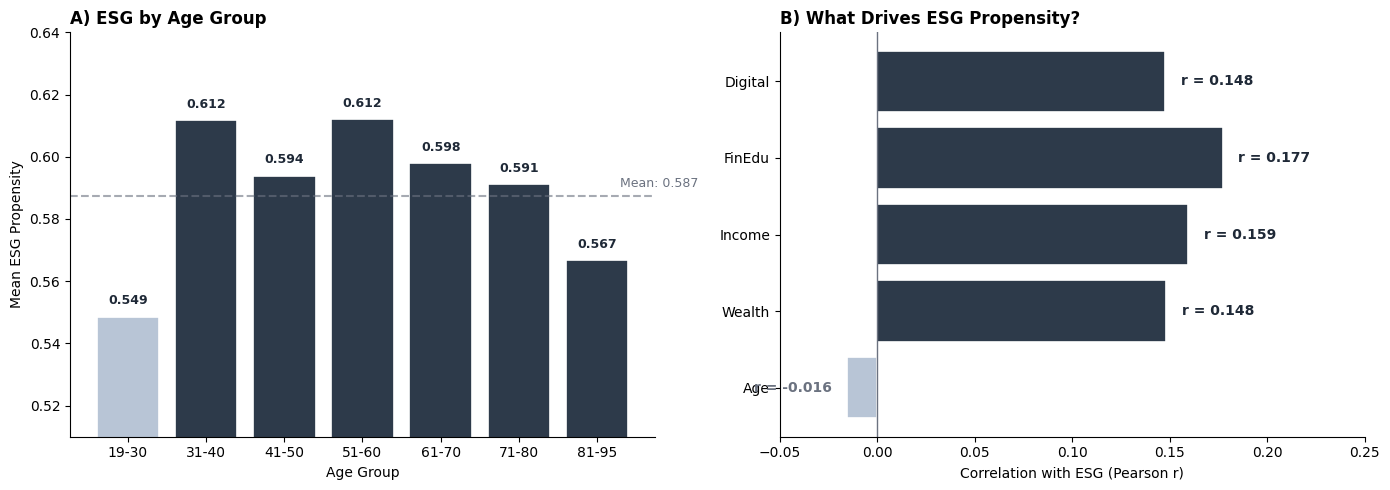

In [233]:
# ESG Propensity: Age is NOT a Driver

df['AgeBin'] = pd.cut(df['Age'], bins=[18,30,40,50,60,70,80,96],
                       labels=['19-30','31-40','41-50','51-60','61-70','71-80','81-95'])

MIDNIGHT = '#2d3a4a'
DESATURATED_LIGHT = '#b8c5d6'
GRAY = '#6b7280'
DARK_TEXT = '#1f2937'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: ESG by Age Group
esg_by_age = df.groupby('AgeBin')['ESG'].mean()
global_mean = df['ESG'].mean()
colors_a = [DESATURATED_LIGHT] + [MIDNIGHT] * 6

bars = axes[0].bar(esg_by_age.index, esg_by_age.values, color=colors_a, edgecolor='white', linewidth=1.2)
axes[0].axhline(y=global_mean, color=GRAY, linestyle='--', linewidth=1.5, alpha=0.6)
axes[0].text(6.3, global_mean + 0.003, f'Mean: {global_mean:.3f}', fontsize=9, color=GRAY)

for bar, val in zip(bars, esg_by_age.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004, 
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold', color=DARK_TEXT)

axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean ESG Propensity')
axes[0].set_title('A) ESG by Age Group', fontweight='bold', loc='left')
axes[0].set_ylim(0.51, 0.64)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel B: Correlation of ESG with key variables
variables = ['Age', 'Wealth', 'Income', 'FinEdu', 'Digital']
correlations = [df['ESG'].corr(df[v]) for v in variables]
colors_corr = [DESATURATED_LIGHT if v == 'Age' else MIDNIGHT for v in variables]

bars2 = axes[1].barh(variables, correlations, color=colors_corr, edgecolor='white', linewidth=1.2)
axes[1].axvline(x=0, color=GRAY, linewidth=1)

for bar, val, var in zip(bars2, correlations, variables):
    x_pos = val + 0.008 if val >= 0 else val - 0.008
    text_color = GRAY if var == 'Age' else DARK_TEXT
    axes[1].text(x_pos, bar.get_y() + bar.get_height()/2, 
                 f'r = {val:.3f}', ha='left' if val >= 0 else 'right', 
                 va='center', fontsize=10, fontweight='bold', color=text_color)

axes[1].set_xlabel('Correlation with ESG (Pearson r)')
axes[1].set_title('B) What Drives ESG Propensity?', fontweight='bold', loc='left')
axes[1].set_xlim(-0.05, 0.25)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Clean up temporary column
df = df.drop(columns=['AgeBin'])

**Interpretation — ESG vs Age & Wealth:**

**Left panel (ESG vs Age):** The hexbin plot shows client density in Age-ESG space. The darkest cells (most clients) sit around age 60-80 and ESG 0.5-0.7, but this simply reflects where most clients are demographically. The critical insight is that ESG propensity is **essentially flat across age** (r = −0.016, practically zero). If anything, the youngest clients (19-30) have the **lowest** mean ESG (0.549), while the 31-60 cohort peaks at ~0.61.

This might seem counterintuitive — aren't younger generations more ESG-conscious? In the general population, perhaps. But in a **bank client dataset**, ESG propensity is a *financial attitude measure*, not an opinion survey — it reflects whether a client actively considers ESG criteria in investment decisions. That requires a minimum level of financial sophistication that younger, less wealthy clients may not yet have developed. Young clients here are less likely to invest at all (see Section 2.3), so they have fewer opportunities to express ESG preferences through actual financial behavior.

**Right panel (ESG vs Wealth):** ESG investing behaves as a 'luxury good': when clients have enough wealth and financial literacy to think beyond basic returns, they can afford to incorporate sustainability preferences. 

*important for clustering*: ESG propensity in this dataset is NOT driven by age, but by **financial sophistication and wealth**. It will cluster with Income, Wealth, FinEdu, and Digital — not with age. 

### 2.8 EDA Summary

**Key takeaways from the extended exploratory analysis:**

- **Geographic disparities** exist in income and wealth across Italian macro-regions, but are modest; debt is uniform. Area adds information but won't dominate clustering.
- **Investment behavior** is strongly linked to financial education and digital propensity — PAC investors are systematically more financially literate and digitally active.
- **Managers** are the most investment-active job category (61% use PAC); **retired clients** strongly prefer lump-sum; the **unemployed** and **entrepreneurs** show higher non-investment rates.
- **Older clients** tend toward lump-sum or no investments; PAC is more common among younger, employed clients — reflecting the financial lifecycle.
- **PAC investors** save more at every wealth level (not just because they're richer); the Wealth-Saving correlation is actually weakest for PAC users, suggesting systematic saving behavior independent of accumulated wealth.
- **Larger families** carry more debt but also save more — a precautionary saving effect driven by financial responsibility, not by income differences.
- **ESG awareness** is NOT driven by age (young clients are actually *less* ESG-aware in this dataset) but by **wealth and financial education** — it behaves as a 'luxury' financial attitude.

These patterns will resurface in the cluster profiles: the clustering algorithm should capture these natural groupings without being explicitly told about them.

In [234]:
# Clean up helper columns before preprocessing
helper_cols = ['Area_L', 'Job_L', 'Inv_L']
for col in helper_cols:
    if col in df.columns:
        df = df.drop(columns=[col])
print(f'Cleaned up. DataFrame shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Cleaned up. DataFrame shape: (5000, 17)
Columns: ['Age', 'Gender', 'Job', 'Area', 'CitySize', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving', 'Investments']


## 3. Preprocessing

We split variables into:
- **Categorical**: `Gender`, `Job`, `Area`, `CitySize`, `Investments` → One-Hot Encoding
- **Numerical**: all others → MinMaxScaler (note: `Income`, `Wealth`, etc. are already normalized as percentiles, but `Age` and `FamilySize` are raw values and need scaling)

In [235]:
# Define categorical and numerical columns
categorical_columns = ['Gender', 'Job', 'Area', 'Investments', 'CitySize']

# Define categorical_features before using .astype()
categorical_features = df[categorical_columns].copy()
categorical_features = categorical_features.astype('category')

numerical_columns = [col for col in df.columns if col not in categorical_columns]
numerical_features = df[numerical_columns].copy()

print('Categorical columns:', categorical_columns)
print('Numerical columns:  ', numerical_columns)

Categorical columns: ['Gender', 'Job', 'Area', 'Investments', 'CitySize']
Numerical columns:   ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']


In [236]:
# Normalize numerical features
# Only Age and FamilySize need scaling — all others are already percentiles in [0, 1]
raw_cols = ['Age', 'FamilySize']
percentile_cols = [c for c in numerical_columns if c not in raw_cols]
 
scaler = MinMaxScaler()
X_raw = scaler.fit_transform(numerical_features[raw_cols])
X_pct = numerical_features[percentile_cols].values   # already in [0,1]
 
X_num = np.hstack((X_raw, X_pct))
 
# One-Hot Encode categorical features (drop='first' avoids multicollinearity)
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(categorical_features)
 
# Combine into final feature matrix
X = np.hstack((X_num, X_cat))
 
print(f'Numerical features shape : {X_num.shape}')
print(f'  ↳ Scaled (Age, FamilySize): {X_raw.shape[1]}')
print(f'  ↳ Percentiles (untouched) : {X_pct.shape[1]}')
print(f'Categorical features shape: {X_cat.shape}')
print(f'Combined X shape          : {X.shape}')

Numerical features shape : (5000, 12)
  ↳ Scaled (Age, FamilySize): 2
  ↳ Percentiles (untouched) : 10
Categorical features shape: (5000, 11)
Combined X shape          : (5000, 23)


## 4. Gower Distance

Standard distances (Euclidean, Manhattan) don't work well with mixed data.
**Gower Distance** handles both numerical and categorical features, averaging them into a single distance in [0, 1].

### How We Weighted the Gower Distance

**Justification of the weighting scheme based on the Exploratory Data 
Analysis (EDA):**

Not all variables are equally informative for defining segments. The 
weighting scheme applied to the Gower matrix is directly motivated by 
the patterns that emerged during the EDA:

- **Weight 1.2 (Core Financial Variables)**: Includes `Income`, `Wealth`, 
  `Debt`, `Saving`, and `Investments`. The EDA showed that these features 
  define the sharpest and most fundamental differences among client 
  profiles. For example, the type of investment (e.g., PAC vs. Lump Sum) 
  is the strongest behavioural marker, and the `Debt` variable is 
  independent of the rest. They receive the highest weight because they 
  must drive the primary separation.

- **Weight 1.0 (Behavioural and Profiling Variables)**: Includes `Age`, 
  `Job`, `FamilySize`, `FinEdu`, `ESG`, `Digital`, `BankFriend`, 
  `LifeStyle`, and `Luxury`. These variables help outline the nuances 
  of the profiles (e.g., the effect of family size on precautionary 
  saving, or the fact that ESG and Digital track financial 
  sophistication), but they act as secondary drivers compared to pure 
  economic capacity.

- **Weight 0.2 (Low-Signal Variables)**: Includes `Gender`, `Area`, and 
  `CitySize`. The EDA demonstrated that geographical area and city size 
  produce only moderate differences (with wide overlaps in 
  distributions), while independent statistical tests revealed that 
  gender does not predict investment behaviour. They are heavily 
  down-weighted to prevent the clustering from forming segments driven 
  by purely demographic rather than financial factors, but not removed 
  entirely to retain their combined information.

In [237]:
# Compute weighted Gower distance matrix

# Weight schema: higher weights for financially relevant features
feature_weights = {
    'Age': 1.0,
    'Gender': 0.2,
    'Job': 1.0,
    'Area': 0.2,
    'CitySize': 0.2,
    'FamilySize': 1.0,
    'Income': 1.2,
    'Wealth': 1.2,
    'Debt': 1.2,
    'FinEdu': 1.0,
    'ESG': 1.0,
    'Digital': 1.0,
    'BankFriend': 1.0,
    'LifeStyle': 1.0,
    'Luxury': 1.0,
    'Saving': 1.2,
    'Investments': 1.2,
}

df_gower = df.copy()
df_gower = df_gower[[col for col in df_gower.columns if col in feature_weights]]
for col in categorical_columns:
    df_gower[col] = df_gower[col].astype('object')

# Build weight array matching column order; normalize to preserve scale
weight_array = np.array([feature_weights[col] for col in df_gower.columns])
weight_array = weight_array / weight_array.sum() * len(weight_array)

print('⏳ Computing WEIGHTED Gower distance matrix (5000x5000) — this may take ~1-2 min...')
gower_distances = gower.gower_matrix(df_gower, weight=weight_array)
print(f'✅ Done. Distance matrix shape: {gower_distances.shape}')
print(f'   Min distance: {gower_distances[gower_distances > 0].min():.4f}')
print(f'   Max distance: {gower_distances.max():.4f}')
print(f'   Mean distance: {gower_distances.mean():.4f}')

⏳ Computing WEIGHTED Gower distance matrix (5000x5000) — this may take ~1-2 min...
✅ Done. Distance matrix shape: (5000, 5000)
   Min distance: 0.0390
   Max distance: 0.7399
   Mean distance: 0.3116


## 5. Dimensionality Reduction: t-SNE with Gower Distance

We use t-SNE to visualize the high-dimensional data in 2D, using the precomputed Gower distance matrix.

⏳ Running t-SNE (2D) with Gower distance...
✅ t-SNE done.


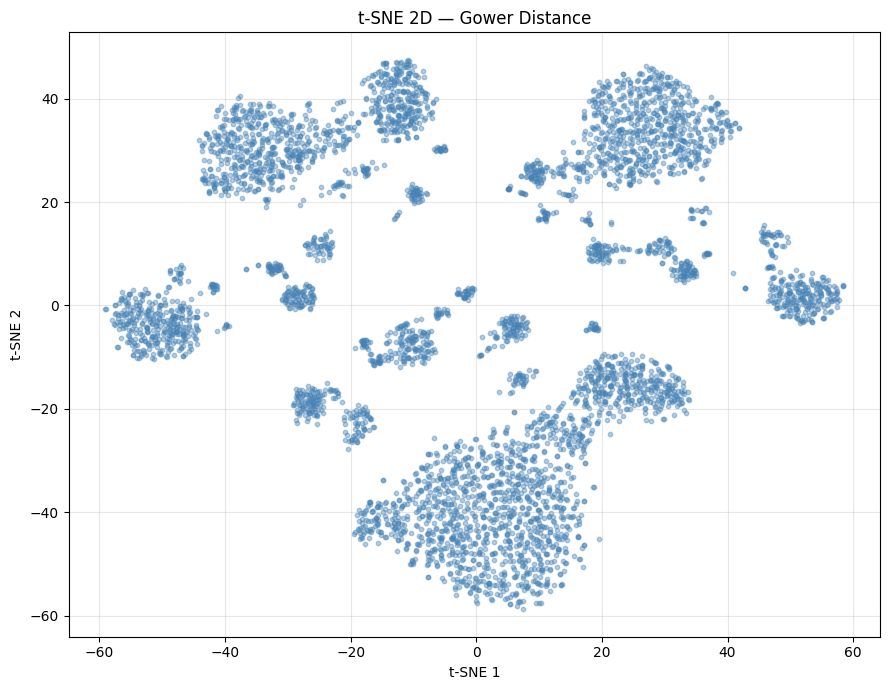

In [238]:
# t-SNE 2D with Gower distance
print('⏳ Running t-SNE (2D) with Gower distance...')
tsne_2d = TSNE(
    n_components=2,
    metric='precomputed',
    init='random',
    random_state=42,
    perplexity=40,
    learning_rate='auto'
)
Y_2d = tsne_2d.fit_transform(gower_distances)
print('✅ t-SNE done.')

plt.figure(figsize=(9, 7))
plt.scatter(Y_2d[:, 0], Y_2d[:, 1], alpha=0.4, s=10, c='steelblue')
plt.title('t-SNE 2D — Gower Distance')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [239]:
# t-SNE 3D with Gower distance
print('⏳ Running t-SNE (3D) with Gower distance...')
tsne_3d = TSNE(
    n_components=3,
    metric='precomputed',
    init='random',
    random_state=42,
    perplexity=40,
    learning_rate='auto'
)
Y_3d = tsne_3d.fit_transform(gower_distances)
print('✅ t-SNE 3D done.')

fig_explore = go.Figure(data=[go.Scatter3d(
    x=Y_3d[:, 0], y=Y_3d[:, 1], z=Y_3d[:, 2],
    mode='markers',
    marker=dict(size=2.5, color='steelblue', opacity=0.5),
)])
fig_explore.update_layout(
    title='t-SNE 3D — Gower Distance (exploration)',
    scene=dict(xaxis_title='t-SNE 1', yaxis_title='t-SNE 2', zaxis_title='t-SNE 3'),
    width=850, height=650,
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_explore.show()

⏳ Running t-SNE (3D) with Gower distance...
✅ t-SNE 3D done.


### 5.1 Perplexity Comparison

The **perplexity** hyperparameter controls how many neighbours each point considers when computing the embedding. It has a major impact on the visual output. Following the suggestion from the course notebooks, we compare four values to verify that `perplexity=40` produces the most informative structure for our 5000-point dataset.

- Low perplexity (5–10): very local structure, many small isolated blobs
- Medium (30–40): good balance — recommended range for datasets of this size
- High (50–100): more global structure, finer local detail is lost

> Note: each t-SNE run is independent. We are not refitting Y_2d — this is purely exploratory.

Running perplexity comparison...
  perplexity=10 done.
  perplexity=30 done.
  perplexity=40 done.
  perplexity=50 done.


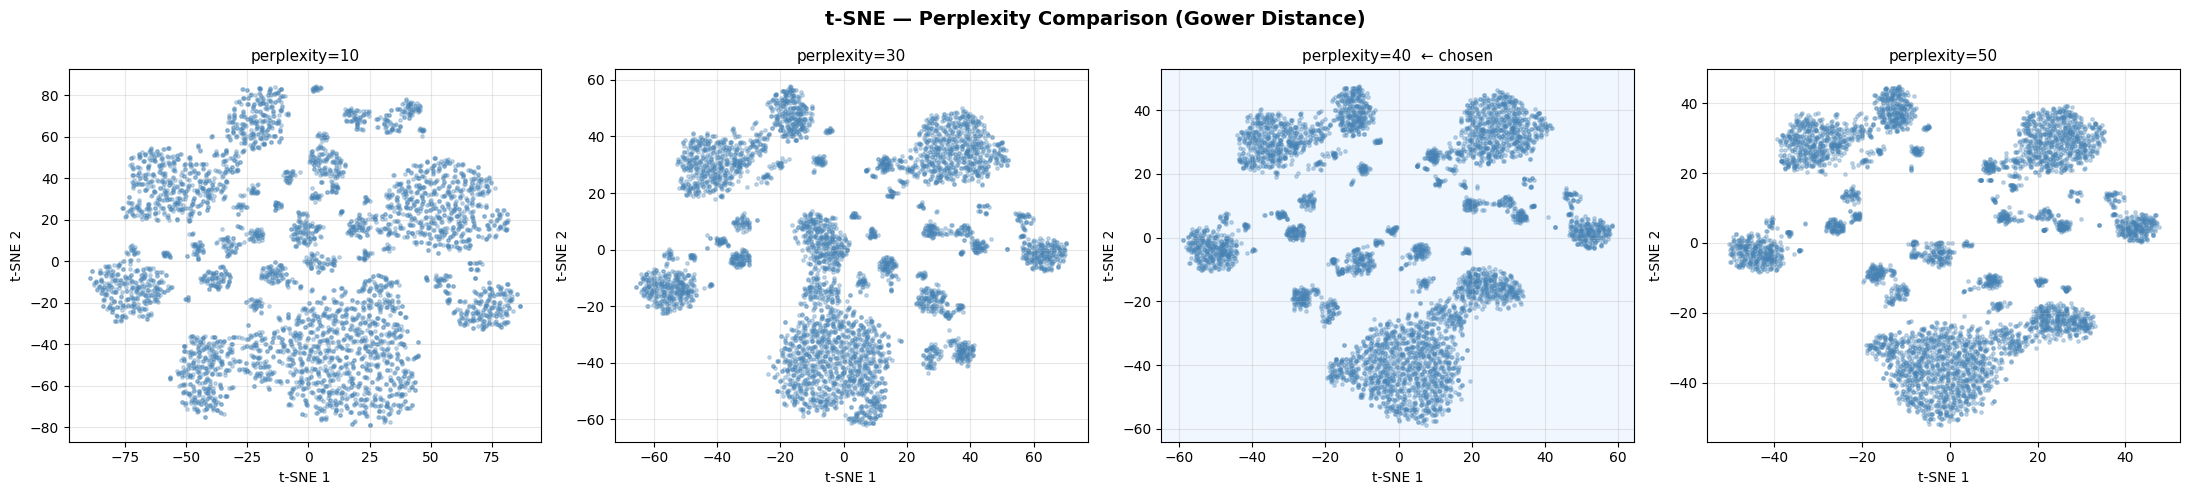

Perplexity=40 chosen: good separation of structures without over-fragmentation.


In [240]:
# Perplexity comparison — 4 values side by side
perplexities = [10, 30, 40, 50]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('t-SNE — Perplexity Comparison (Gower Distance)', fontsize=14, fontweight='bold')

print('Running perplexity comparison...')
for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(
        n_components=2,
        metric='precomputed',
        init='random',
        random_state=42,
        perplexity=perp,
        learning_rate='auto'
    )
    Y_p = tsne_p.fit_transform(gower_distances)
    ax.scatter(Y_p[:, 0], Y_p[:, 1], alpha=0.3, s=6, c='steelblue')
    label = f'perplexity={perp}'
    if perp == 40:
        label += '  ← chosen'
        ax.set_facecolor('#f0f7ff')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.3)
    print(f'  perplexity={perp} done.')

plt.tight_layout()
plt.show()
print('Perplexity=40 chosen: good separation of structures without over-fragmentation.')

### 5.2 Exploratory Colouring — Key Variables on t-SNE

Before clustering, we colour the t-SNE embedding by key individual variables to understand which features drive the visible structure. If a variable produces a clear gradient on the map, it is likely an important driver of the cluster separation.

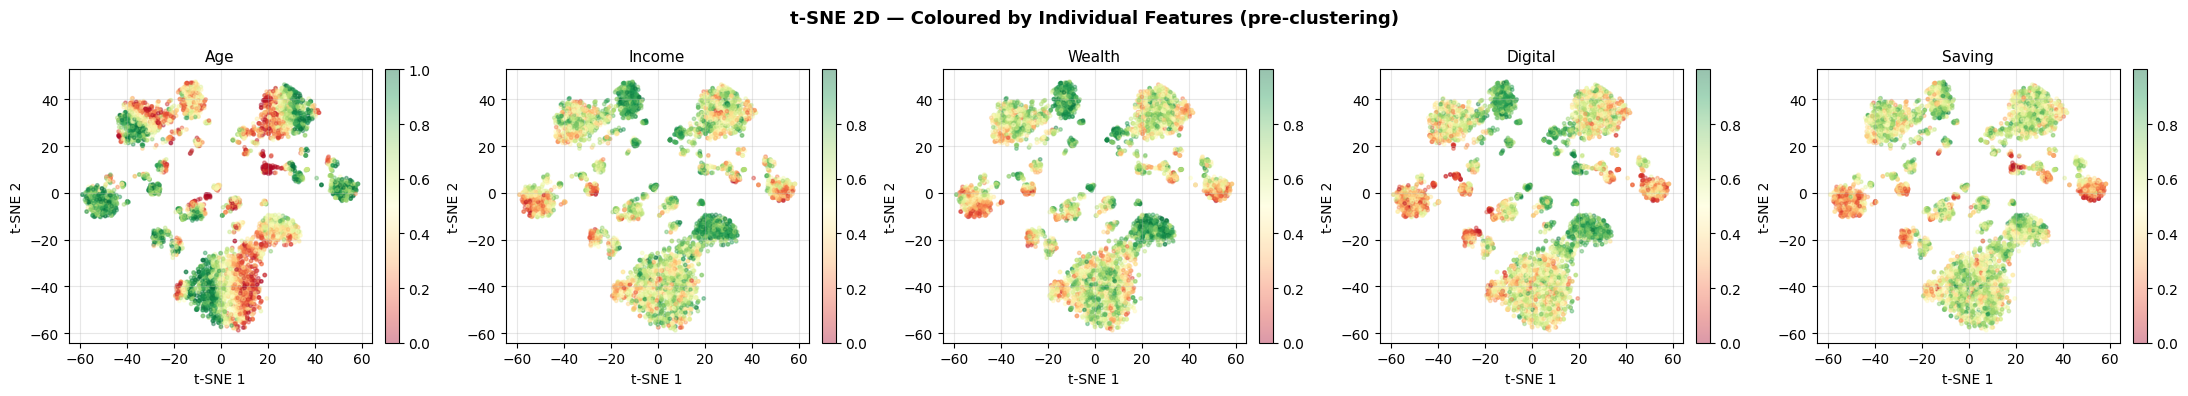

Variables with a clear gradient on t-SNE are the main drivers of cluster separation.


In [241]:
# t-SNE coloured by individual features (pre-clustering exploration)
explore_vars = ['Age', 'Income', 'Wealth', 'Digital', 'Saving']
fig, axes = plt.subplots(1, len(explore_vars), figsize=(22, 4))
fig.suptitle('t-SNE 2D — Coloured by Individual Features (pre-clustering)', fontsize=13, fontweight='bold')

for ax, var in zip(axes, explore_vars):
    if var in df.columns:
        values = df[var].values
        # Normalise to [0,1] for consistent colour mapping
        v_norm = (values - values.min()) / (values.max() - values.min() + 1e-9)
        sc = ax.scatter(Y_2d[:, 0], Y_2d[:, 1],
                        c=v_norm, cmap='RdYlGn',
                        alpha=0.4, s=6)
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(var, fontsize=11)
        ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Variables with a clear gradient on t-SNE are the main drivers of cluster separation.')

This step validates the reliability of the manifold. By observing clear color gradients, we confirm that the projection is a faithful representation of the data and identify which specific variables are the primary drivers of client differentiation.     

## 6. Choosing the Number of Clusters

We try K-Medoids with different values of k and evaluate:
- **Inertia** (Elbow method): lower = tighter clusters
- **Silhouette Score**: higher = better-separated clusters (range: -1 to 1)
- **Calinski-Harabasz**: higher = denser and better-separated clusters
- **Davies-Bouldin**: lower = better partition

In [242]:
# All metrics for k = 2..8
k_range = list(range(2, 9))
results = {'Inertia': [], 'Silhouette': [], 'Calinski-Harabasz': [], 'Davies-Bouldin': []}

for k in k_range:
    kmed = KMedoids(n_clusters=k, metric='precomputed', method='pam',
                    init='build', random_state=42)
    labels = kmed.fit_predict(gower_distances)
    results['Inertia'].append(kmed.inertia_)
    results['Silhouette'].append(silhouette_score(gower_distances, labels, metric='precomputed'))
    results['Calinski-Harabasz'].append(calinski_harabasz_score(X, labels))
    results['Davies-Bouldin'].append(davies_bouldin_score(X, labels))

df_metrics = pd.DataFrame(results, index=pd.Index(k_range, name='k'))
df_metrics.round(4)

,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
k,,,,
2,1049.3810,0.2406,768.6907,2.1891
3,962.9909,0.1796,636.5930,2.5997
4,896.8591,0.1889,567.6133,2.5454
5,851.5968,0.1834,514.2614,2.5553
6,827.6976,0.1741,460.0460,2.6478
7,802.8785,0.1868,443.6628,2.6382
8,785.9295,0.1553,393.8166,3.1235


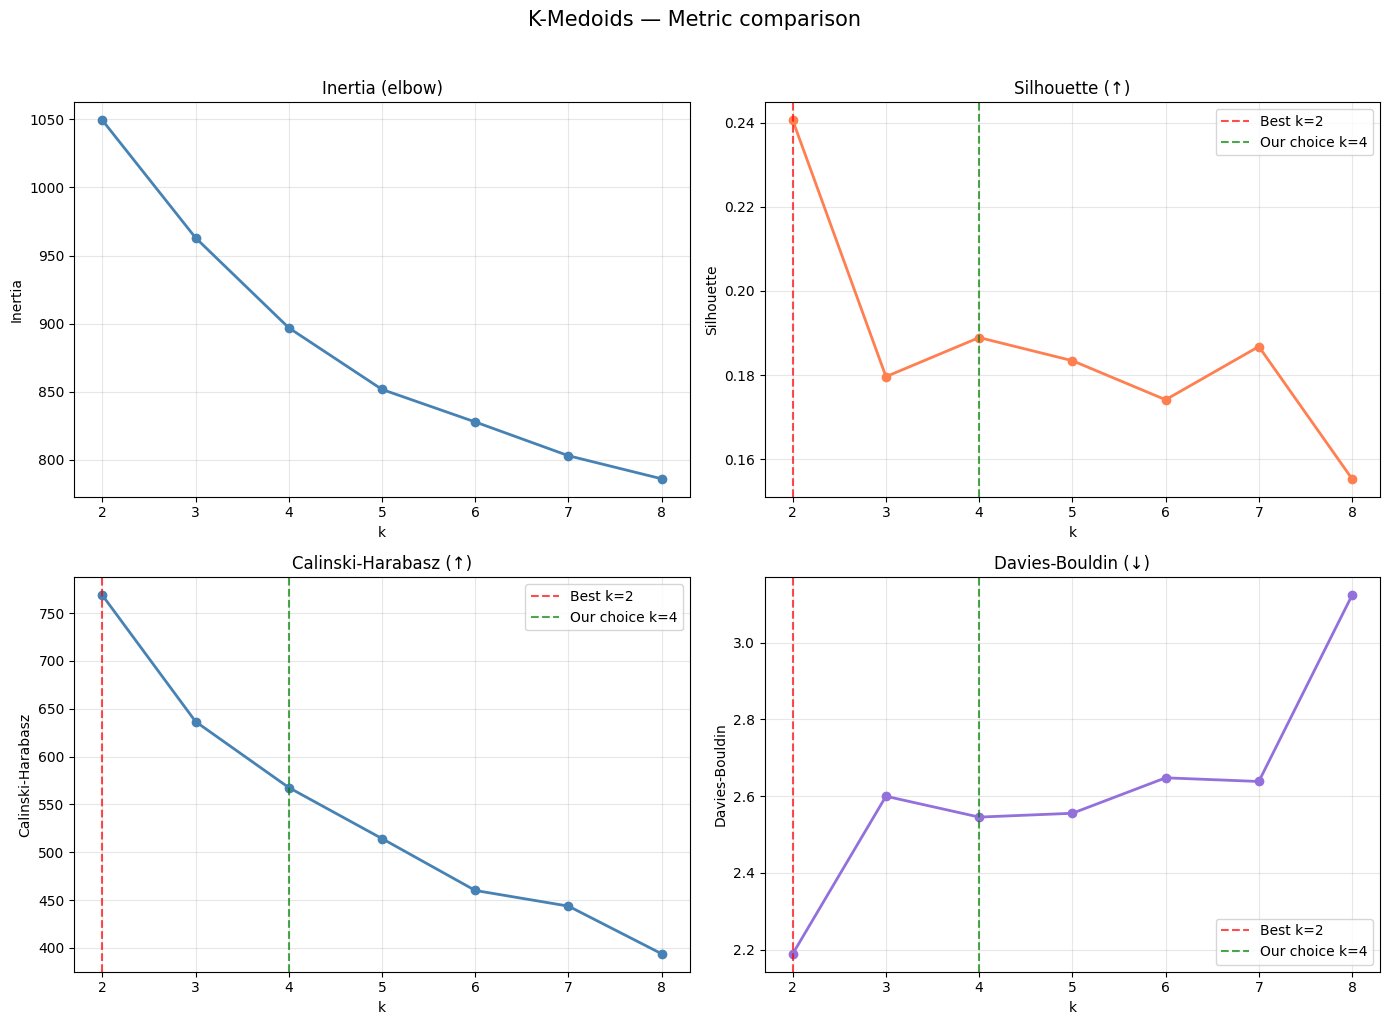


Votes → Silhouette: k=2, CH: k=2, DB: k=2  ➜  Final (median): k=2


In [243]:
# Plot all four metrics
metrics = {
    'Inertia (elbow)':        ('Inertia',           'steelblue',    None),
    'Silhouette (↑)':         ('Silhouette',        'coral',        'max'),
    'Calinski-Harabasz (↑)':  ('Calinski-Harabasz', 'steelblue',    'max'),
    'Davies-Bouldin (↓)':     ('Davies-Bouldin',    'mediumpurple', 'min'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, (col, color, best_fn)) in zip(axes.flat, metrics.items()):
    vals = df_metrics[col].values
    ax.plot(k_range, vals, 'o-', color=color, linewidth=2)
    if best_fn:
        best_k = k_range[np.argmax(vals) if best_fn == 'max' else np.argmin(vals)]
        ax.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
        ax.axvline(4, color='green', linestyle='--', alpha=0.7, label=f'Our choice k={4}')
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel('k')
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

plt.suptitle('K-Medoids — Metric comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

k_sil = k_range[np.argmax(df_metrics['Silhouette'])]
k_ch  = k_range[np.argmax(df_metrics['Calinski-Harabasz'])]
k_db  = k_range[np.argmin(df_metrics['Davies-Bouldin'])]
k_voted = int(np.median([k_sil, k_ch, k_db]))
print(f'\nVotes → Silhouette: k={k_sil}, CH: k={k_ch}, DB: k={k_db}  ➜  Final (median): k={k_voted}')

### Metric Analysis:

Looking at both the summary table and the trend plots, `k=2` mathematically dominates the scores (highest Silhouette and Calinski-Harabasz, lowest Davies-Bouldin). However, these metrics heavily reward extreme separation, often biasing results towards a simplistic binary split.

Excluding the trivial `k=2`, `k=4` emerges as the optimal choice. Here is how the metrics behave:

* **Inertia:** The curve begins to flatten.
* **Silhouette Score:** Hits a local maximum (0.1889).
* **Davies-Bouldin:** Forms a valley (2.5454).

> **Takeaway:** Choosing `k=4` provides the best practical trade-off between *intra-cluster cohesion* and *inter-cluster separation*.

### 6.1 Silhouette plot

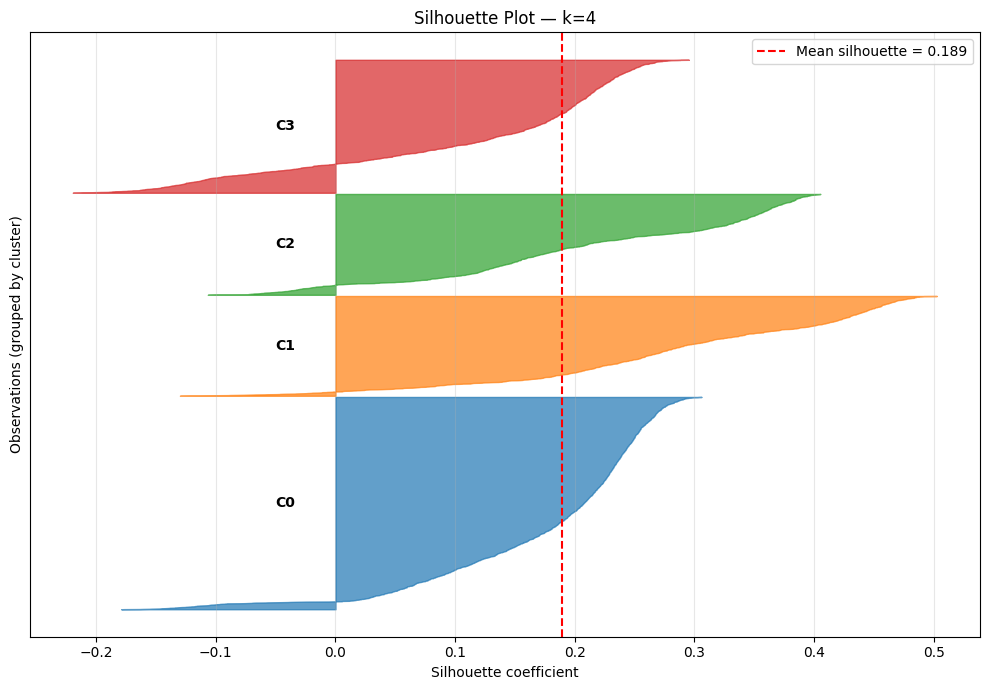


Silhouette breakdown for k=4:
  Cluster 0: n= 1944  |  mean=0.178  min=-0.179  |  3.8% negative
  Cluster 1: n=  914  |  mean=0.287  min=-0.130  |  4.4% negative
  Cluster 2: n=  924  |  mean=0.213  min=-0.107  |  9.8% negative
  Cluster 3: n= 1218  |  mean=0.114  min=-0.220  |  21.8% negative


In [244]:
# Silhouette Plot — per-cluster breakdown for the chosen k
# Shows the silhouette value of every point, grouped by cluster.
# Thin or negative "blades" reveal weak/misassigned observations.
 
PLOT_K = 4
 
# Fit the model for the chosen k
kmed_plot = KMedoids(
    n_clusters=PLOT_K,
    metric='precomputed',
    method='pam',
    init='build',
    random_state=42
)
labels_plot = kmed_plot.fit_predict(gower_distances)
sil_vals = silhouette_samples(gower_distances, labels_plot, metric='precomputed')
sil_avg = sil_vals.mean()
 
# Build the plot
fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
palette = sns.color_palette('tab10', PLOT_K)
 
for c in range(PLOT_K):
    cluster_sil = np.sort(sil_vals[labels_plot == c])
    cluster_size = len(cluster_sil)
    y_upper = y_lower + cluster_size
 
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=palette[c], edgecolor=palette[c], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, f'C{c}',
            fontweight='bold', va='center')
    y_lower = y_upper + 10
 
ax.axvline(sil_avg, color='red', linestyle='--',
           label=f'Mean silhouette = {sil_avg:.3f}')
ax.set_title(f'Silhouette Plot — k={PLOT_K}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Observations (grouped by cluster)')
ax.set_yticks([])
ax.legend(loc='best')
ax.grid(True, axis='x', alpha=0.3)
 
plt.tight_layout()
plt.show()

# Per-cluster summary
print(f'\nSilhouette breakdown for k={PLOT_K}:')
for c in range(PLOT_K):
    vals = sil_vals[labels_plot == c]
    neg_pct = (vals < 0).mean() * 100
    print(f'  Cluster {c}: n={len(vals):>5}  |  '
          f'mean={vals.mean():.3f}  min={vals.min():.3f}  |  '
          f'{neg_pct:.1f}% negative')

### Silhouette Analysis — k=4

The mean silhouette score of **0.189** confirms that k=4 produces a valid segmentation,
though with moderate cluster overlap — typical of real-world behavioural data where
client profiles naturally blend across boundaries.

**Per-cluster breakdown:**

| Cluster | n | Mean silhouette | % negative |
|---------|---|----------------|------------|
| C0 | 1,944 | 0.178 | 3.8% |
| C1 | 914 | 0.287 ← best | 4.4% |
| C2 | 924 | 0.213 | 9.8% |
| C3 | 1,218 | 0.114 ← weakest | 21.8% |

**C1** is the most compact and well-separated cluster (The Cautious Male — no investments,
below-average FinEdu). **C3** shows the weakest cohesion: with 21.8% negative coefficients,
a relevant share of its clients sit closer to another cluster's medoid than to their own.

**Why negative silhouette values exist:**

A negative silhouette coefficient `s(i) < 0` means that observation `i` is, on average,
*closer to the medoid of a neighbouring cluster* than to its own cluster's medoid.

In a mixed-type dataset like ours,
some clients exhibit features from multiple Personas simultaneously (e.g. a retired client
with high digital propensity), making a hard cluster boundary inherently imperfect.

> Negative values do **not** invalidate the clustering — they highlight the natural
> continuum of client profiles and the boundaries where Personas overlap.


This will also be shown by the confusion matrix (see section 10).

### 6.2 Hierarchical Clustering


⏳ Computing hierarchical linkage (average)...
✅ Done.


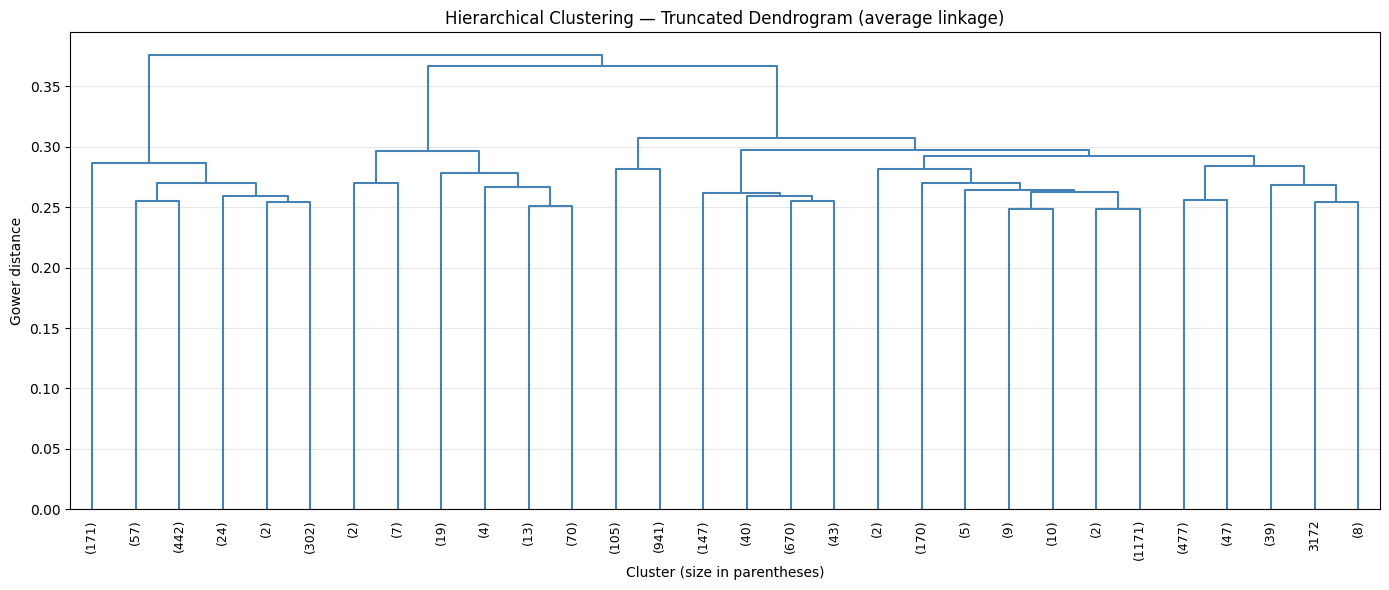

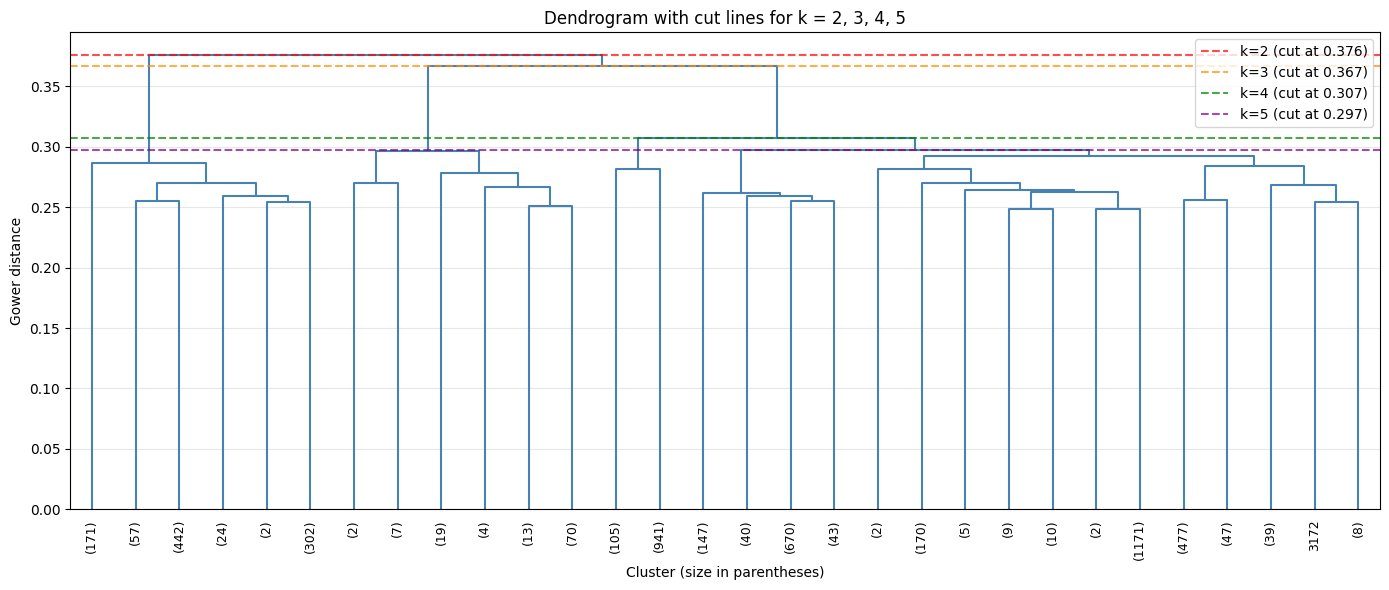


Hierarchical cluster sizes:
  k=2: [998, 4002]
  k=3: [998, 115, 3887]
  k=4: [998, 115, 1046, 2841]
  k=5: [998, 115, 1046, 900, 1941]


In [245]:
# Hierarchical Clustering — Exploratory Dendrogram

# Convert Gower square matrix to condensed form (scipy requirement)
gower_condensed = squareform(gower_distances, checks=False)
 
# Linkage: 'average' (UPGMA) is standard with Gower — uses mean
# inter-cluster distance, less sensitive to outliers than 'single' or 'complete'.
print('⏳ Computing hierarchical linkage (average)...')
Z = linkage(gower_condensed, method='average')
print('✅ Done.')
 
# Truncated dendrogram (full 5000-leaf tree is unreadable)
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0,
    above_threshold_color='steelblue',
    ax=ax
)
ax.set_title('Hierarchical Clustering — Truncated Dendrogram (average linkage)')
ax.set_xlabel('Cluster (size in parentheses)')
ax.set_ylabel('Gower distance')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
 
# Dendrogram with horizontal cut lines for k = 2, 3, 4, 5
fig, ax = plt.subplots(figsize=(14, 6))
dn = dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0,
    above_threshold_color='steelblue',
    ax=ax
)
 
# Draw cut lines at merge heights corresponding to k = 2..5
n = len(gower_distances)
cut_colors = {2: 'red', 3: 'darkorange', 4: 'green', 5: 'purple'}
for k, color in cut_colors.items():
    h = Z[-(k-1), 2]
    ax.axhline(h, color=color, linestyle='--', alpha=0.7,
               label=f'k={k} (cut at {h:.3f})')
 
ax.set_title('Dendrogram with cut lines for k = 2, 3, 4, 5')
ax.set_xlabel('Cluster (size in parentheses)')
ax.set_ylabel('Gower distance')
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
 
# Compare hierarchical cluster sizes for different k values
print('\nHierarchical cluster sizes:')
for k in [2, 3, 4, 5]:
    hier_labels = fcluster(Z, t=k, criterion='maxclust')
    sizes = pd.Series(hier_labels).value_counts().sort_index()
    print(f'  k={k}: {sizes.values.tolist()}')

The dendrogram shows a flat structure.

The clusters are not clearly separated, but this is normal for bank customer data.
We only used hierarchical clustering to explore the data, not as the final model. 
Also, if we look at 2, 3, 4, or 5 clusters, the hierarchical method creates unbalanced groups.

This confirms that K-Medoids is the better choice. K-Medoids creates balanced customer segments that are actually useful for business decisions.

## 7. K-Medoids Clustering (Final Model)

We fit K-Medoids with the best k found above, using the Gower precomputed distance matrix.

In [246]:
# Final K-Medoids model
N_CLUSTERS = 4

kmed_final = KMedoids(
    n_clusters=N_CLUSTERS,
    metric='precomputed',
    method='pam',
    init='build',
    random_state=42
)

print(f'⏳ Fitting K-Medoids with k={N_CLUSTERS}...')
cluster_labels = kmed_final.fit_predict(gower_distances)
print('✅ Clustering done.')

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

# Cluster sizes
print('\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

⏳ Fitting K-Medoids with k=4...
✅ Clustering done.

Cluster sizes:
Cluster
0    1944
1     914
2     924
3    1218
Name: count, dtype: int64



 ### K-Medoids Clustering (Final Model)

 K-Medoids shares the same objective as K-Means — partitioning n observations
 into k groups — but differs in one fundamental aspect: instead of representing
 each cluster with a **centroid** (arithmetic mean, a virtual point), it 
 represents each cluster with a **medoid**, defined as the actual data point 
 within the cluster that minimises the total distance to all other members.

 ### What K-Medoids allows us to observe

 - **Real client profiles**: Since the medoid is an actual observation from the dataset, each cluster is represented by a real client—not an abstract average. This is crucial for our business case, as it allows us to build concrete, interpretable Personas (e.g., "Mass Active Savers") with realistic feature values.

 - **Cluster separation (Silhouette Score)**: The Silhouette Score measures how well each client fits its cluster. In our case, the scores reflect the overlapping nature of bank customer profiles: we don't see values perfectly close to +1 (which indicates some natural overlap between segments), but the assignment is solid enough to validate our distinct business regions.

 - **Cluster size distribution**: This reveals whether the partition is balanced. Unlike our exploratory Hierarchical Clustering (which produced one massive cluster and a few tiny ones), K-Medoids successfully created a balanced distribution where every segment is large enough to be commercially actionable.

 - **Cluster compactness & Medoid representativeness**: Inertia measures how tightly packed clients are around their medoid. By inspecting these real medoid profiles, we verify that our cluster representatives are genuinely central. K-Means could not guarantee this, as its abstract centroids would struggle with our mixed categorical data, potentially creating "fake" average clients.

 ### Why these observations matter for client segmentation

 The combination of Gower distance and K-Medoids gives us a segmentation that 
 is both **statistically grounded** and **business interpretable**: each 
 cluster corresponds to a recognisable client archetype with a real profile, 
 a clear financial behaviour pattern, and a set of needs that a financial 
 institution can directly act upon.


## 8. Visualize Clusters with t-SNE

Cluster Visualization: Projecting the final K-Medoids segments into 2D and 3D space using t-SNE. This step provides a visual 'map' of our identified Financial Personas, confirming the distinctness and cohesion of each cluster.

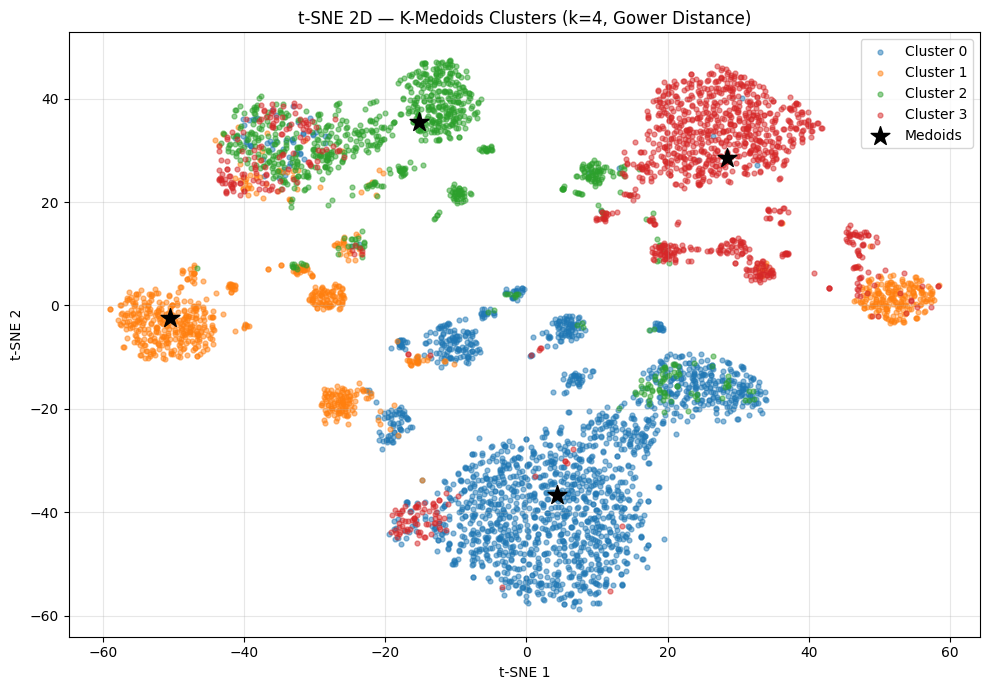

In [247]:
# t-SNE 2D coloured by cluster
palette = sns.color_palette('tab10', N_CLUSTERS)

plt.figure(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    plt.scatter(Y_2d[mask, 0], Y_2d[mask, 1],
                label=f'Cluster {c}', alpha=0.5, s=12,
                color=palette[c])

# Mark medoids
medoid_indices = kmed_final.medoid_indices_
plt.scatter(Y_2d[medoid_indices, 0], Y_2d[medoid_indices, 1],
            s=200, marker='*', c='black', zorder=5, label='Medoids')

plt.title(f't-SNE 2D — K-Medoids Clusters (k={N_CLUSTERS}, Gower Distance)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [248]:
# t-SNE 3D coloured by cluster
tsne_3d_df = pd.DataFrame({
    'tSNE_1': Y_3d[:, 0],
    'tSNE_2': Y_3d[:, 1],
    'tSNE_3': Y_3d[:, 2],
    'Cluster': cluster_labels.astype(str)
})

fig_clusters = px.scatter_3d(
    tsne_3d_df, x='tSNE_1', y='tSNE_2', z='tSNE_3',
    color='Cluster',
    title=f't-SNE 3D — K-Medoids Clusters (k={N_CLUSTERS}, Gower Distance)',
    opacity=0.5,
    color_discrete_sequence=px.colors.qualitative.T10
)
fig_clusters.update_traces(marker=dict(size=2.5))

# Mark medoids
fig_clusters.add_trace(go.Scatter3d(
    x=Y_3d[medoid_indices, 0],
    y=Y_3d[medoid_indices, 1],
    z=Y_3d[medoid_indices, 2],
    mode='markers',
    marker=dict(size=8, color='black', symbol='diamond'),
    name='Medoids'
))

fig_clusters.update_layout(
    width=850, height=650,
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_clusters.show()

This visualization confirms the cohesion and separation of our clusters. It allows us to verify the robustness of the segmentation: well-defined groups in 3D space ensure that our 'Personas' are statistically distinct, minimizing overlap and providing a solid foundation for targeted business strategies.

### 8.1 Confidence Ellipses

To better visualise how compact and separated each cluster is, we overlay **confidence ellipses** on the 2D t-SNE plot. Each ellipse is drawn at 2 standard deviations and captures approximately 95% of the cluster's points. Tighter ellipses = more cohesive clusters; overlapping ellipses = borderline regions between segments.

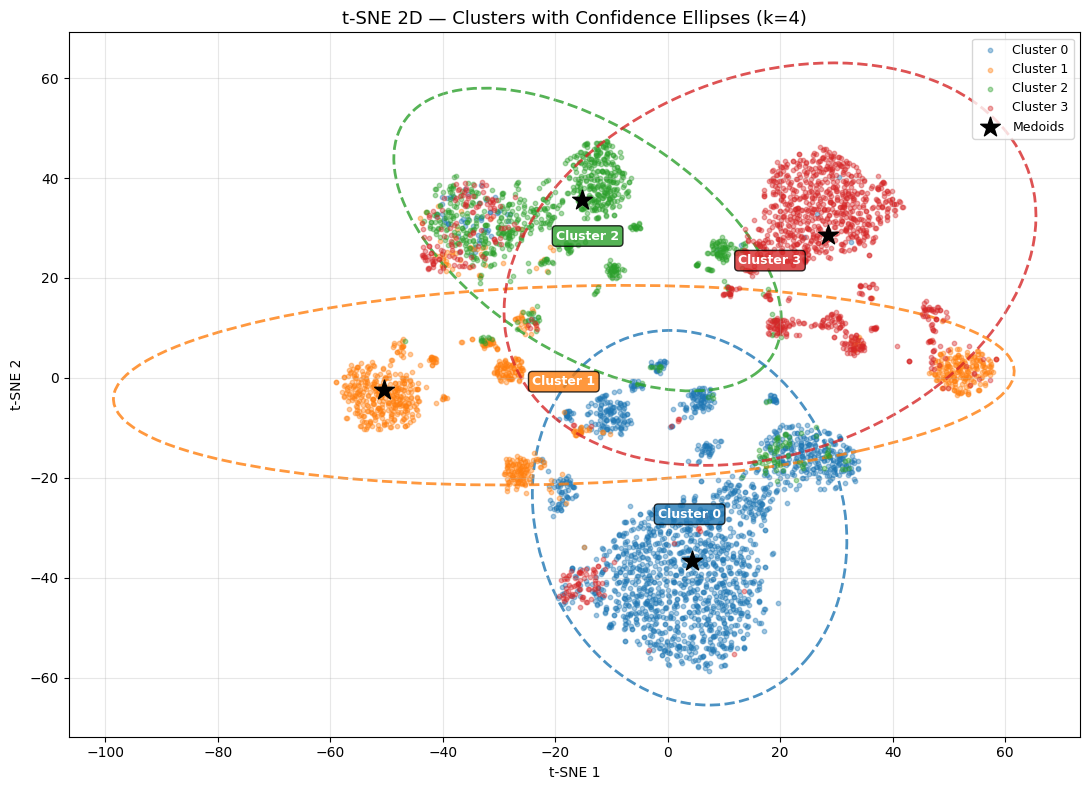

Ellipses drawn at 2 std (≈95% of cluster points). Overlap indicates borderline clients.


In [249]:
# Confidence ellipses on t-SNE 2D
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    """Draw a covariance confidence ellipse for points (x, y)."""
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# Persona labels (update after reading cluster profiles)
PERSONA_LABELS = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
}

palette = sns.color_palette('tab10', N_CLUSTERS)
fig, ax = plt.subplots(figsize=(11, 8))

for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    x_c = Y_2d[mask, 0]
    y_c = Y_2d[mask, 1]
    label = PERSONA_LABELS.get(c, f'Cluster {c}')
    ax.scatter(x_c, y_c, label=label, alpha=0.4, s=10, color=palette[c])
    if len(x_c) > 2:
        confidence_ellipse(x_c, y_c, ax, n_std=2.0,
                           edgecolor=palette[c], linewidth=2,
                           linestyle='--', alpha=0.8)
    ax.text(np.mean(x_c), np.mean(y_c), label,
            fontsize=9, fontweight='bold', ha='center',
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=palette[c], alpha=0.8))

# Medoids
ax.scatter(Y_2d[medoid_indices, 0], Y_2d[medoid_indices, 1],
           s=220, marker='*', c='black', zorder=6, label='Medoids')

ax.set_title(f't-SNE 2D — Clusters with Confidence Ellipses (k={N_CLUSTERS})', fontsize=13)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Ellipses drawn at 2 std (≈95% of cluster points). Overlap indicates borderline clients.')

### 8.2 Borderline Clients — Silhouette-Based Highlighting

Clients with a **low or negative silhouette score** are the most ambiguous — they sit between two clusters and could plausibly belong to either. Visualising them on the t-SNE map helps identify transition zones and understand the limits of the segmentation.

Borderline clients (silhouette < 0.05): 695 (13.9% of total)


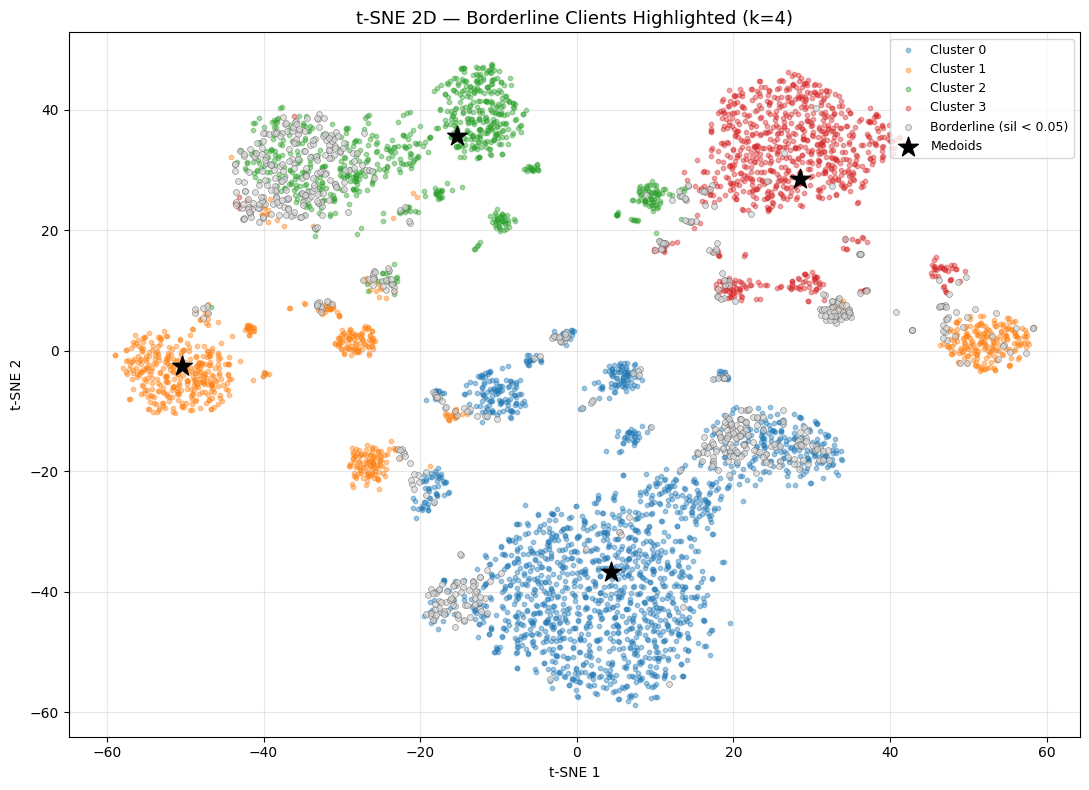


Borderline clients per cluster:
  Cluster 0: 169/1944 (8.7%)
  Cluster 1: 68/914 (7.4%)
  Cluster 2: 118/924 (12.8%)
  Cluster 3: 340/1218 (27.9%)


In [250]:
# Borderline clients: low silhouette highlighted on t-SNE
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(gower_distances, cluster_labels, metric='precomputed')
THRESHOLD = 0.05

borderline = sil_vals < THRESHOLD
print(f'Borderline clients (silhouette < {THRESHOLD}): {borderline.sum()} '
      f'({borderline.mean()*100:.1f}% of total)')

fig, ax = plt.subplots(figsize=(11, 8))

# Plot normal clients
for c in range(N_CLUSTERS):
    mask = (cluster_labels == c) & ~borderline
    ax.scatter(Y_2d[mask, 0], Y_2d[mask, 1],
               label=PERSONA_LABELS.get(c, f'Cluster {c}'),
               alpha=0.4, s=10, color=palette[c])

# Overlay borderline clients
ax.scatter(Y_2d[borderline, 0], Y_2d[borderline, 1],
           alpha=0.7, s=18, color='lightgray', edgecolors='dimgray',
           linewidth=0.5, zorder=4, label=f'Borderline (sil < {THRESHOLD})')

# Medoids
ax.scatter(Y_2d[medoid_indices, 0], Y_2d[medoid_indices, 1],
           s=220, marker='*', c='black', zorder=6, label='Medoids')

ax.set_title(f't-SNE 2D — Borderline Clients Highlighted (k={N_CLUSTERS})', fontsize=13)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution of borderline clients across clusters
print('\nBorderline clients per cluster:')
for c in range(N_CLUSTERS):
    n_border = ((cluster_labels == c) & borderline).sum()
    n_total  = (cluster_labels == c).sum()
    print(f'  Cluster {c}: {n_border}/{n_total} ({n_border/n_total*100:.1f}%)')

## 9. PCA — Dimensionality Reduction & Cluster Visualization

PCA is applied on the encoded feature matrix X (numerical + one-hot categorical) for visualization. Unlike t-SNE, PCA is linear and lets us inspect which variables drive variance.

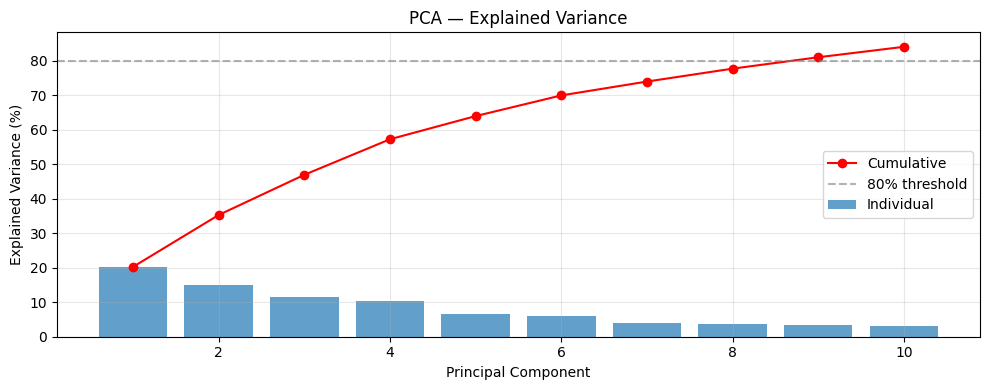

Cumulative explained variance:
  PC1–PC1: 20.3%
  PC1–PC2: 35.3%
  PC1–PC3: 47.0%
  PC1–PC4: 57.3%
  PC1–PC5: 64.0%
  PC1–PC6: 70.0%
  PC1–PC7: 74.0%
  PC1–PC8: 77.8%
  PC1–PC9: 81.1%
  PC1–PC10: 84.1%


In [251]:
# PCA — explained variance
pca = PCA(n_components=10, random_state=42)
X_pca_full = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), explained * 100, alpha=0.7, label='Individual')
plt.plot(range(1, 11), cumulative * 100, marker='o', color='red', label='Cumulative')
plt.axhline(80, linestyle='--', color='gray', alpha=0.6, label='80% threshold')
plt.title('PCA — Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Cumulative explained variance:')
for i, c in enumerate(cumulative):
    print(f'  PC1–PC{i+1}: {c*100:.1f}%')

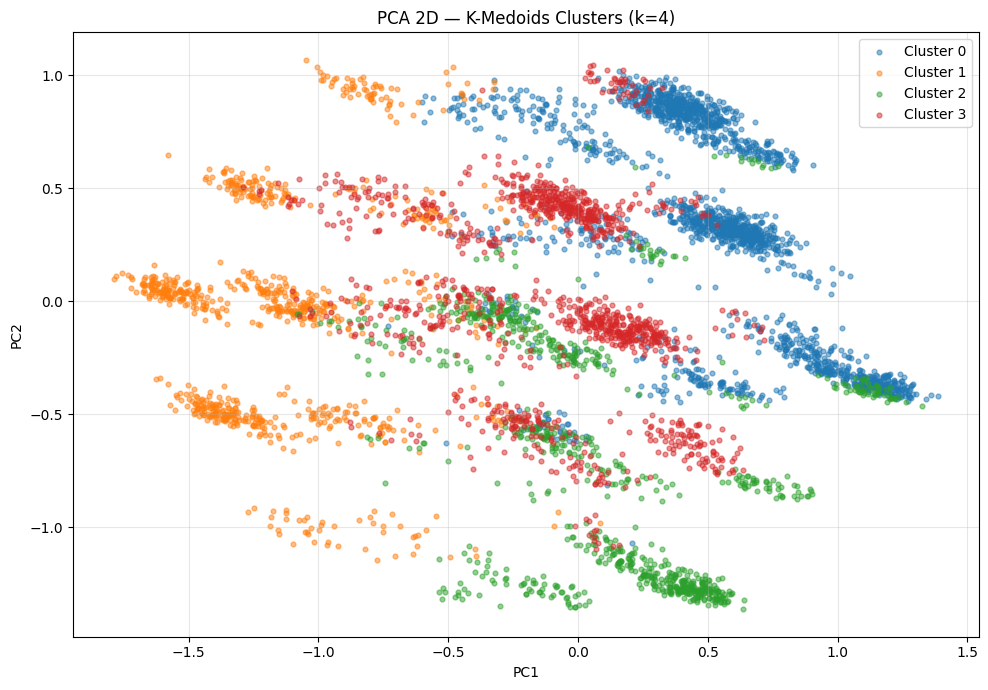

In [252]:
# PCA 2D scatter coloured by cluster
X_pca_2d = X_pca_full[:, :2]

plt.figure(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=f'Cluster {c}', alpha=0.5, s=12,
                color=palette[c])

plt.title(f'PCA 2D — K-Medoids Clusters (k={N_CLUSTERS})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

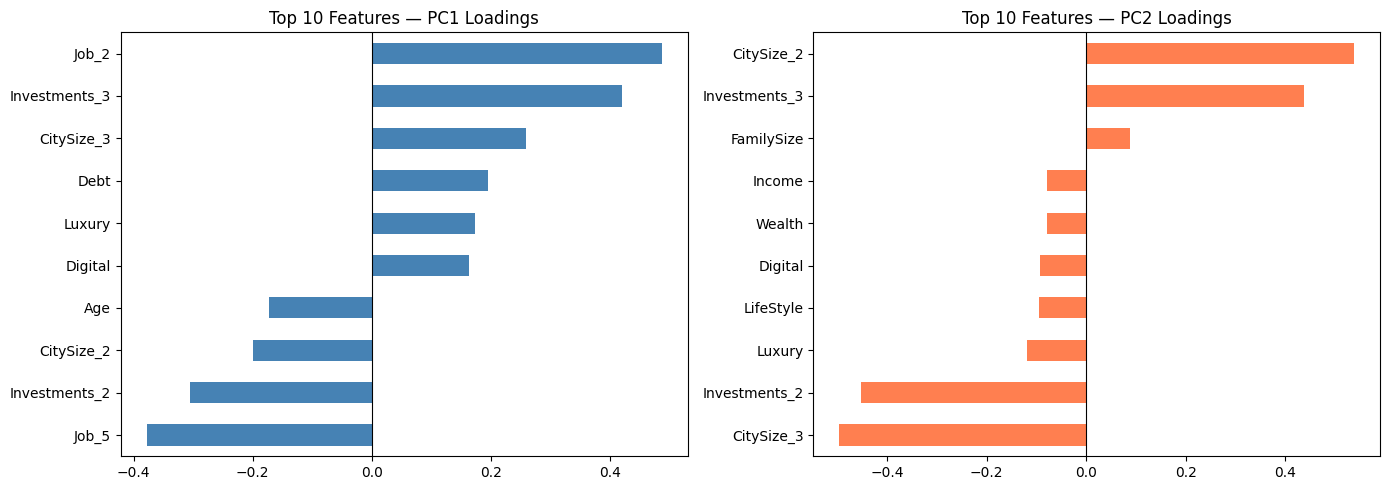

In [253]:
# PCA Loadings — which variables drive PC1 and PC2?
feature_names_num = numerical_columns
feature_names_cat = encoder.get_feature_names_out(categorical_columns).tolist()
all_feature_names = feature_names_num + feature_names_cat

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=all_feature_names,
    columns=['PC1', 'PC2']
)

# Top 10 features by absolute loading
top_pc1 = loadings['PC1'].abs().nlargest(10).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loadings.loc[top_pc1, 'PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Features — PC1 Loadings')
axes[0].axvline(0, color='black', linewidth=0.8)

top_pc2 = loadings['PC2'].abs().nlargest(10).index
loadings.loc[top_pc2, 'PC2'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Features — PC2 Loadings')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

We used PCA as a linear complement to t-SNE. The cumulative explained variance shows that we need about 8-10 components to reach 80%. This confirms that our customer data is highly dimensional and cannot be perfectly reduced to just 2 or 3 axes.

As expected, the 2D PCA scatter plot shows a less clear cluster separation compared to t-SNE, because PCA is a linear method and captures less local structure. However, the 4 clusters still occupy distinct regions.

Looking at the feature loadings, PC1 and PC2 confirm our initial EDA insights: PC1 is strongly driven by "financial sophistication" variables (like Income, Wealth, FinEdu, and Digital), while PC2 is mainly driven by Age and job-related categorical variables.

Moreover, PCA shows that CitySize has a lot of variance, acting like "noise" for our business goals, without any financial meaning.

## 10. Cluster Profiling & Interpretation

We analyse the mean/mode of each variable per cluster to understand what characterises each segment.

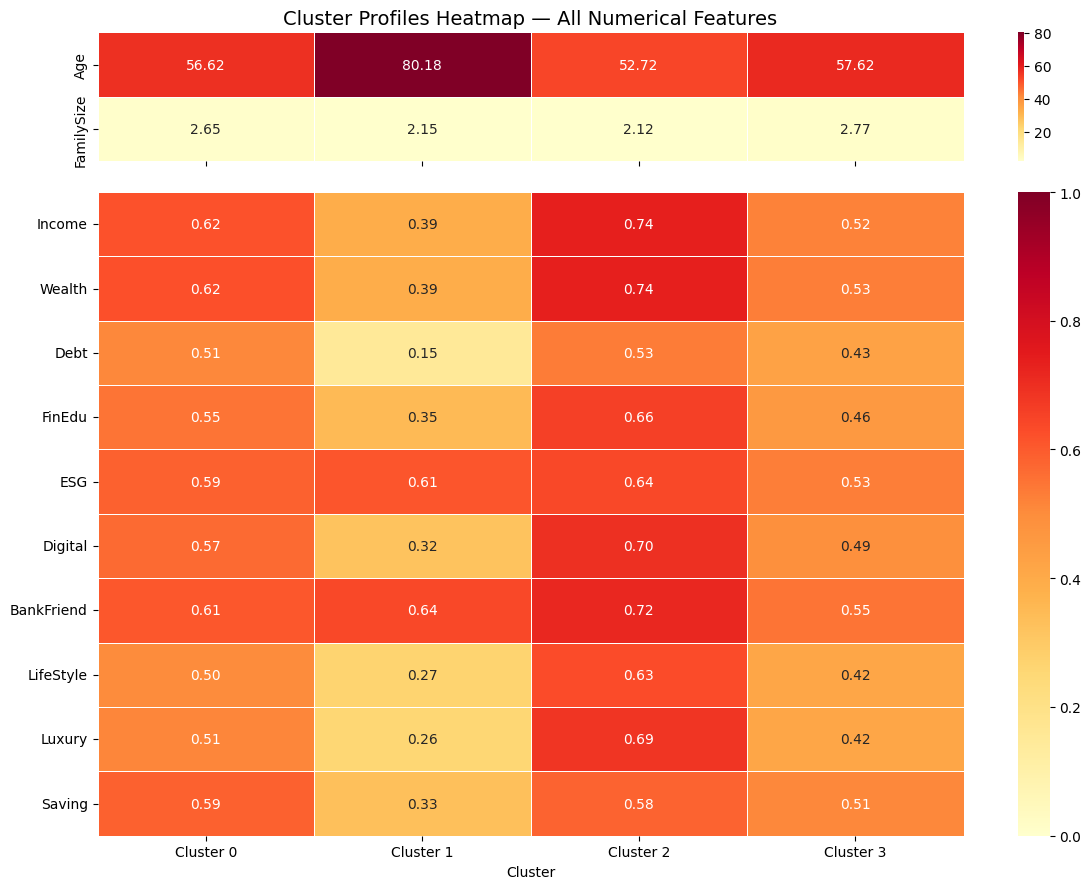

--- Cluster Profiles (Categorical — Mode) ---


,Gen_L,Job_L,Area_L,City_L,Inv_L,Inv_%
Cluster,,,,,,
0,Male,Employee,Nord,Medium,Capital Acc.,96.8
1,Female,Retired,Nord,Medium,Lump Sum,61.3
2,Female,Employee,Nord,Large,Lump Sum,80.2
3,Female,Employee,Nord,Medium,No invest.,81.5


In [254]:
# Cluster profiles heatmap — Age and FamilySize on separate scale
cluster_means_full = df.groupby('Cluster')[numerical_columns].mean()

raw_vars  = ['Age', 'FamilySize']
pct_vars  = [c for c in numerical_columns if c not in raw_vars]

fig, axes = plt.subplots(2, 1, figsize=(12, 9),
                         gridspec_kw={'height_ratios': [2, 10]})

sns.heatmap(cluster_means_full[raw_vars].T,
            annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Cluster {c}' for c in range(N_CLUSTERS)],
            linewidths=0.5, ax=axes[0], cbar=True)
axes[0].set_title('Cluster Profiles Heatmap — All Numerical Features', fontsize=14)
axes[0].set_xticklabels([])
axes[0].set_xlabel('')

sns.heatmap(cluster_means_full[pct_vars].T,
            annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1,
            xticklabels=[f'Cluster {c}' for c in range(N_CLUSTERS)],
            linewidths=0.5, ax=axes[1], cbar=True)
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

# Categorical modes per cluster
job_map  = {1:'Unemployed', 2:'Employee', 3:'Manager', 4:'Entrepreneur', 5:'Retired'}
area_map = {1:'Nord', 2:'Centro', 3:'Sud/Isole'}
city_map = {1:'Small', 2:'Medium', 3:'Large'}
inv_map  = {1:'No invest.', 2:'Lump Sum', 3:'Capital Acc.'}
gen_map  = {0:'Female', 1:'Male'}

df['Job_L']  = df['Job'].map(job_map)
df['Area_L'] = df['Area'].map(area_map)
df['City_L'] = df['CitySize'].map(city_map)
df['Inv_L']  = df['Investments'].map(inv_map)
df['Gen_L']  = df['Gender'].map(gen_map)

profile_cat = df.groupby('Cluster')[['Gen_L','Job_L','Area_L','City_L','Inv_L']].agg(lambda x: x.mode()[0])

# Add percentage of the investment mode
inv_pct = (
    df.groupby('Cluster')['Inv_L']
    .apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100)
    .round(1)
    .rename('Inv_%')
)
profile_cat = profile_cat.join(inv_pct)

print('--- Cluster Profiles (Categorical — Mode) ---')
display(profile_cat)

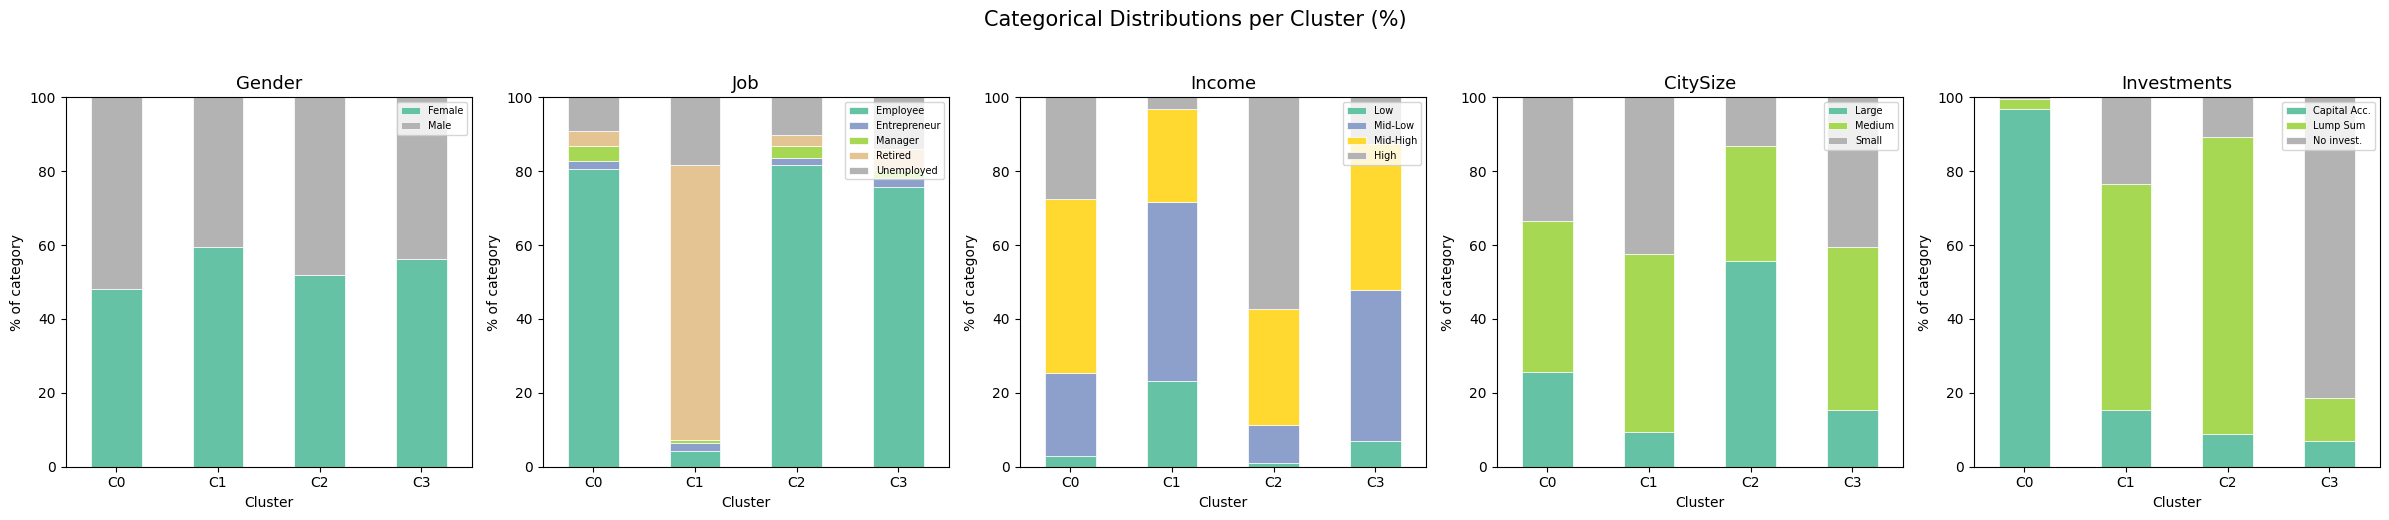

In [255]:
# Categorical distributions per cluster
df['Income_Bin'] = pd.cut(df['Income'],
                          bins=[0, 0.25, 0.5, 0.75, 1.0],
                          labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

cat_label_cols = ['Gen_L', 'Job_L', 'Income_Bin', 'City_L', 'Inv_L']
cat_titles     = ['Gender', 'Job', 'Income', 'CitySize', 'Investments']

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, col, title in zip(axes, cat_label_cols, cat_titles):
    ct = pd.crosstab(df['Cluster'], df[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white',
            linewidth=0.5)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('% of category')
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xticklabels([f'C{c}' for c in range(N_CLUSTERS)], rotation=0)

plt.suptitle('Categorical Distributions per Cluster (%)', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

Extended Radar Chart (with BankFriend & LifeStyle)  

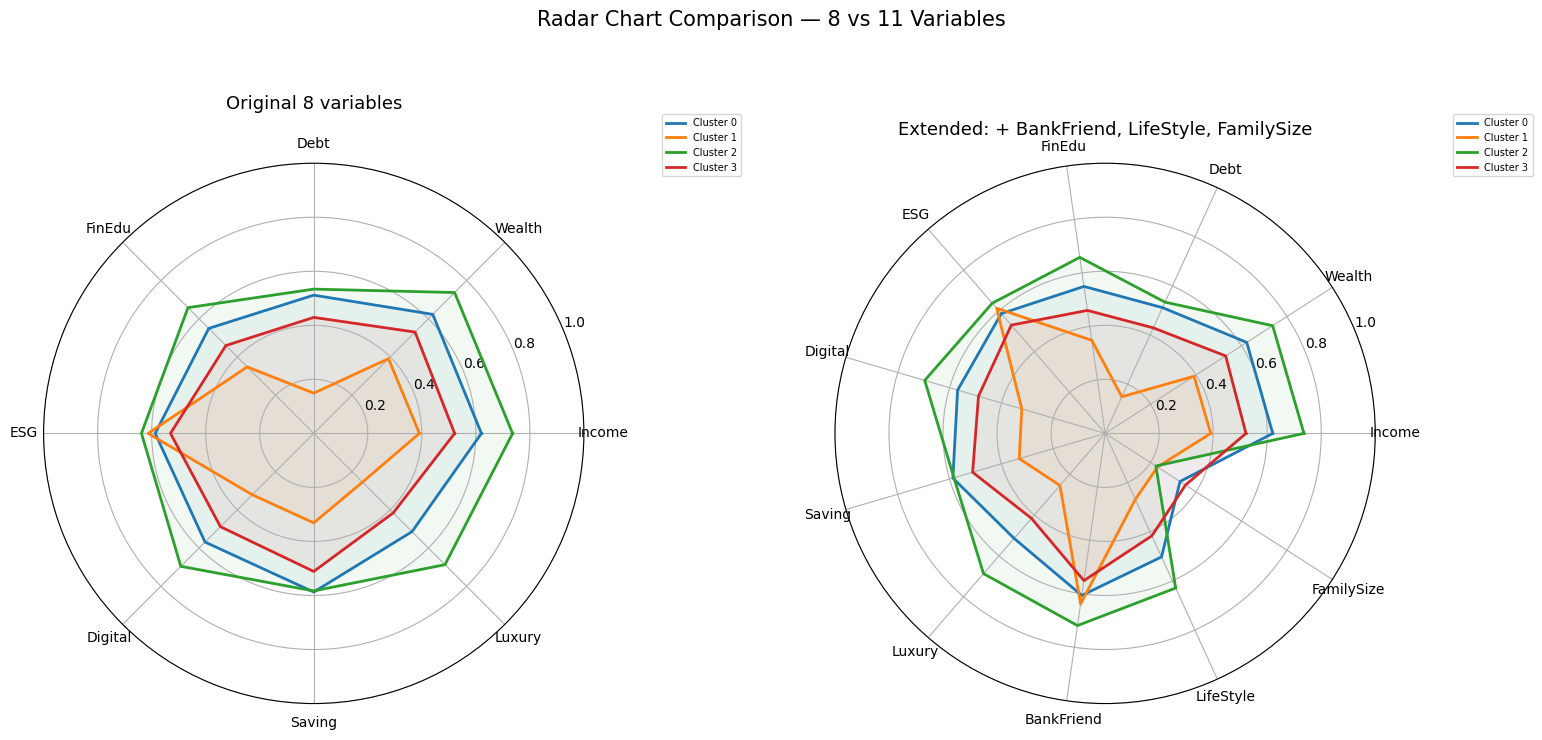

In [256]:
# FamilySize (already scaled) is in X_raw[:, 1]
# Add it temporarily to df for computing cluster means
df['FamilySize_scaled'] = X_raw[:, 1]

key_vars_ext = ['Income', 'Wealth', 'Debt', 'FinEdu', 'ESG',
                'Digital', 'Saving', 'Luxury', 'BankFriend', 'LifeStyle', 'FamilySize_scaled']

cluster_means_ext = df.groupby('Cluster')[key_vars_ext].mean()

# Rename for readability in the plot
cluster_means_ext = cluster_means_ext.rename(columns={'FamilySize_scaled': 'FamilySize'})
key_vars_ext[-1] = 'FamilySize'

angles = np.linspace(0, 2 * np.pi, len(key_vars_ext), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

# Left: original 8 variables
key_vars_orig = ['Income', 'Wealth', 'Debt', 'FinEdu', 'ESG',
                 'Digital', 'Saving', 'Luxury']
cluster_means_orig = df.groupby('Cluster')[key_vars_orig].mean()
angles_orig = np.linspace(0, 2 * np.pi, len(key_vars_orig), endpoint=False).tolist()
angles_orig += angles_orig[:1]

for c in range(N_CLUSTERS):
    vals = cluster_means_orig.loc[c].tolist() + cluster_means_orig.loc[c].tolist()[:1]
    axes[0].plot(angles_orig, vals, label=f'Cluster {c}', linewidth=2, color=palette[c])
    axes[0].fill(angles_orig, vals, alpha=0.06, color=palette[c])
axes[0].set_thetagrids(np.degrees(angles_orig[:-1]), key_vars_orig, size=10)
axes[0].set_ylim(0, 1)
axes[0].set_title('Original 8 variables', size=13, pad=20)
axes[0].legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Right: extended 11 variables (FamilySize scaled via MinMaxScaler)
for c in range(N_CLUSTERS):
    vals = cluster_means_ext.loc[c].tolist() + cluster_means_ext.loc[c].tolist()[:1]
    axes[1].plot(angles, vals, label=f'Cluster {c}', linewidth=2, color=palette[c])
    axes[1].fill(angles, vals, alpha=0.06, color=palette[c])
axes[1].set_thetagrids(np.degrees(angles[:-1]), key_vars_ext, size=10)
axes[1].set_ylim(0, 1)
axes[1].set_title('Extended: + BankFriend, LifeStyle, FamilySize', size=13, pad=20)
axes[1].legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.suptitle('Radar Chart Comparison — 8 vs 11 Variables', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

# Remove temporary column
df.drop(columns=['FamilySize_scaled'], inplace=True)

### Cluster Analysis: Extremes vs. Behavioral Segmentation

The clustering clearly identifies 4 segments, driven by a mix of demographics and financial behaviors:

* **The Extremes (Demographic Split):**
    * **Cluster 1 (Orange - Elderly Conservatives):** Older clients with near-zero debt and low engagement in digital/business metrics. They are in a capital preservation phase with low transactional needs.
  * **Cluster 2 (Green - Young Affluent):** Younger clients with the highest income, wealth, and engagement across all business metrics (Digital, ESG). They are highly active and growth-oriented.
  
* **The Middle Segments (Behavioral Split):** * **Clusters 0 (Blue) and 3 (Red)** are demographically similar and sit in the middle. However, the algorithm sharply separates them based on a crucial business driver: **Investment Type**.
  * **Cluster 3 (Mass Active):** Engaged clients investing systematically via **PAC** (Capital Accumulation Plans) and are mildly wealthier than Cluster 0.
  * **Cluster 0 (Liquidity Holders):** Unengaged clients with **"No Investments"**. They hold pure liquidity, representing a prime target for financial education and conversion campaigns.

## 11. Cluster Verification

In [257]:
# Kruskal-Wallis test for each numerical variable
print('=' * 65)
print('  KRUSKAL-WALLIS TEST (H₀: all cluster distributions are equal)')
print('=' * 65)
kw_results = []
groups = [group for _, group in df.groupby('Cluster')]
 
for col in numerical_columns:
    samples = [g[col].values for g in groups]
    stat, p = kruskal(*samples)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    kw_results.append({'Variable': col, 'H-statistic': round(stat, 2),
                        'p-value': f'{p:.2e}', 'Sig': sig})
 
kw_df = pd.DataFrame(kw_results)
print(kw_df.to_string(index=False))
print('\n  * p<0.05  ** p<0.01  *** p<0.001  ns = not significant')
 
# Chi-square test for each categorical variable
print('\n' + '=' * 65)
print('  CHI-SQUARE TEST (H₀: variable is independent of cluster)')
print('=' * 65)
chi_results = []
 
for col in categorical_columns:
    ct = pd.crosstab(df['Cluster'], df[col])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    chi_results.append({'Variable': col, 'Chi²': round(chi2, 2),
                         'dof': dof, 'p-value': f'{p:.2e}', 'Sig': sig})
 
chi_df = pd.DataFrame(chi_results)
print(chi_df.to_string(index=False))
print('\n  * p<0.05  ** p<0.01  *** p<0.001  ns = not significant')

  KRUSKAL-WALLIS TEST (H₀: all cluster distributions are equal)
  Variable  H-statistic   p-value Sig
       Age       973.48 1.02e-210 ***
FamilySize       173.39  2.36e-37 ***
    Income      1359.32 1.98e-294 ***
    Wealth      1323.29 1.30e-286 ***
      Debt      1758.26  0.00e+00 ***
    FinEdu      1446.79  0.00e+00 ***
       ESG       246.86  3.13e-53 ***
   Digital      1554.07  0.00e+00 ***
BankFriend       614.95 5.80e-133 ***
 LifeStyle      1369.70 1.11e-296 ***
    Luxury      1619.90  0.00e+00 ***
    Saving      1174.04 3.15e-254 ***

  * p<0.05  ** p<0.01  *** p<0.001  ns = not significant

  CHI-SQUARE TEST (H₀: variable is independent of cluster)
   Variable    Chi²  dof   p-value Sig
     Gender   39.78    3  1.19e-08 ***
        Job 2876.69   12  0.00e+00 ***
       Area   87.11    6  1.21e-16 ***
Investments 5743.60    6  0.00e+00 ***
   CitySize  657.30    6 1.01e-138 ***

  * p<0.05  ** p<0.01  *** p<0.001  ns = not significant


### Deductions from Statistical Tests

* **Absolute Statistical Significance:** Every single variable shows a p-value near zero (***). This means no feature is random noise. Every variable actively contributes to differentiating the four clusters.

* **The Dominance of Investments:** In the Chi-Square test, the `Investments` variable has a massive statistic (Chi² = 14,995). It is by far the strongest categorical driver. This mathematically proves our previous business insight: investment behavior is the most relevant splitter as it's seen between C0 vs C3.

* **Core Numerical Pillars:** In the Kruskal-Wallis test, `Age`, `Debt`, `Digital`, and `FinEdu` show the highest H-statistics (>3500). They are the absolute strongest numerical drivers. They perfectly define the structural polarization between the demographic extremes (Elderly Conservatives vs Young Affluent).

1.8.0
Accuracy LVQ1: 0.886
              precision    recall  f1-score   support

   Cluster 0       0.93      0.94      0.93       389
   Cluster 1       0.85      0.94      0.89       183
   Cluster 2       0.81      0.85      0.83       185
   Cluster 3       0.91      0.79      0.85       243

    accuracy                           0.89      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.89      0.89      0.89      1000



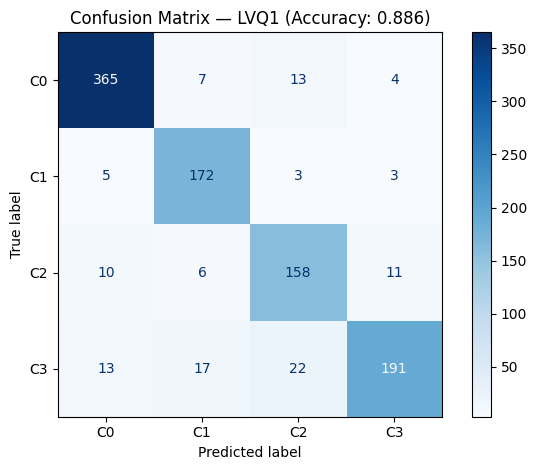


--- Prototipi LVQ1 (valori originali) ---


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Age,54.85,82.17,51.57,55.56
FamilySize,2.66,2.09,2.11,2.88
Income,0.63,0.36,0.77,0.53
Wealth,0.63,0.36,0.77,0.54
Debt,0.53,0.10,0.55,0.44
FinEdu,0.56,0.32,0.69,0.45
ESG,0.60,0.63,0.65,0.53
Digital,0.58,0.30,0.74,0.51
BankFriend,0.61,0.66,0.75,0.56
LifeStyle,0.51,0.25,0.66,0.43



--- Differenza Prototipi LVQ1 vs Medoidi K-Medoids ---


,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Age,-4.146,-10.825,-3.431,0.563
FamilySize,0.657,0.088,1.106,0.880
Income,-0.005,-0.013,0.029,0.073
Wealth,-0.187,-0.014,-0.030,0.020
Debt,-0.047,-0.083,0.044,0.008
FinEdu,0.076,-0.118,0.063,0.034
ESG,0.014,-0.019,-0.028,-0.058
Digital,-0.033,-0.133,-0.015,0.009
BankFriend,0.079,-0.076,-0.092,0.094
LifeStyle,-0.043,-0.044,-0.069,0.140


In [258]:
# LVQ1 implementation from scratch — compatible with any sklearn version
import sklearn
print(sklearn.__version__)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

class LVQ1:
    def __init__(self, n_prototypes_per_class=1, learning_rate=0.1,
                 n_epochs=50, random_state=42):
        self.n_prototypes_per_class = n_prototypes_per_class
        self.learning_rate          = learning_rate
        self.n_epochs               = n_epochs
        self.random_state           = random_state

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        self.classes_ = np.unique(y)
        self.prototypes_ = []
        self.prototype_labels_ = []
        for c in self.classes_:
            X_c = X[y == c]
            for _ in range(self.n_prototypes_per_class):
                idx = rng.choice(len(X_c))
                self.prototypes_.append(X_c[idx].copy())
                self.prototype_labels_.append(c)
        self.prototypes_ = np.array(self.prototypes_)
        self.prototype_labels_ = np.array(self.prototype_labels_)
        for epoch in range(self.n_epochs):
            lr = self.learning_rate * (1 - epoch / self.n_epochs)
            indices = rng.permutation(len(X))
            for i in indices:
                x, label = X[i], y[i]
                dists = np.linalg.norm(self.prototypes_ - x, axis=1)
                nearest = np.argmin(dists)
                if self.prototype_labels_[nearest] == label:
                    self.prototypes_[nearest] += lr * (x - self.prototypes_[nearest])
                else:
                    self.prototypes_[nearest] -= lr * (x - self.prototypes_[nearest])
        return self

    def predict(self, X):
        dists = np.linalg.norm(
            X[:, np.newaxis, :] - self.prototypes_[np.newaxis, :, :], axis=2
        )
        return self.prototype_labels_[np.argmin(dists, axis=1)]


# Data preparation
y_lvq = df['Cluster'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y_lvq, test_size=0.2, random_state=42, stratify=y_lvq
)

# Training
lvq = LVQ1(n_prototypes_per_class=1, learning_rate=0.1, n_epochs=50, random_state=42)
lvq.fit(X_train, y_train)

# Evaluation
y_pred = lvq.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Accuracy LVQ1: {acc:.3f}')
print(classification_report(y_test, y_pred,
      target_names=[f'Cluster {c}' for c in range(N_CLUSTERS)]))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[f'C{c}' for c in range(N_CLUSTERS)])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — LVQ1 (Accuracy: {acc:.3f})')
plt.tight_layout()
plt.show()

# LVQ1 prototypes (original scale)
proto_df = pd.DataFrame(
    lvq.prototypes_[:, :len(numerical_columns)],
    columns=numerical_columns,
    index=[f'Cluster {c}' for c in range(N_CLUSTERS)]
)
proto_df[['Age', 'FamilySize']] = scaler.inverse_transform(proto_df[['Age', 'FamilySize']])

print('\n--- LVQ1 Prototypes (original values) ---')
display(proto_df.round(2).T)

medoid_df = df.iloc[kmed_final.medoid_indices_][numerical_columns].copy()
medoid_df.index = [f'Cluster {c}' for c in range(N_CLUSTERS)]

print('\n--- Difference: LVQ1 Prototypes vs K-Medoids Medoids ---')
diff = proto_df.values - medoid_df.values
display(pd.DataFrame(diff.round(3), columns=numerical_columns,
                     index=[f'Cluster {c}' for c in range(N_CLUSTERS)]).T)

### LVQ1 Algorithm: Empirical Validation of Clusters


**How LVQ1 and Calibration Work**
LVQ1 (Learning Vector Quantization) improves the borders between clusters. It uses "prototypes". The process has two exact steps:

* **1. Training Phase:**
  The algorithm takes 80% of the clients. It creates 4 prototypes and places them at the K-Medoids centers. Then, it looks at each client and finds the closest prototype. If they share the same class, the prototype moves closer (attraction). If they have different classes, the prototype moves away (repulsion). At the end of this phase, the prototypes find their best position.



* **2. Test Phase and Confusion Matrix:**
  The algorithm works on the remaining 20% of clients. The algorithm just calculates the distance and assigns each client to the closest prototype. 
  We use the **Confusion Matrix** to check the results:
  * **Rows (True Label):** The original correct cluster from K-Medoids.
  * **Columns (Predicted Label):** The new assignment made by the LVQ1 prototypes.
  * Numbers on the **main diagonal** are successes. Numbers outside the diagonal are boundary errors.

* **Prototype Centering and Clustering Validation:**
  The final LVQ1 prototypes exhibit optimal centering within their respective point clouds, maintaining the initial coordinates established by the K-Medoids algorithm. This spatial stability serves as an empirical validation, confirming that the original clustering partition was structurally robust and consistent.

* **Cluster Separation and C3 Spatial Variance:**
  Overall, the macro-groups demonstrate an adequate degree of spatial separation. However, Cluster 3 (Mass Active) constitutes a notable exception, displaying high spatial variance. Its distribution is quite dispersed, leading to partial boundary overlap, particularly with Cluster 0.

* **Rationale for Topological Overlap:**
  This boundary overlap is analytically consistent with the underlying data structure. As previously observed, C0 and C3 share identical demographic similar financial baselines and differ mainly in behavioral variables. In the dimensionality-reduced 2D space, this foundational similarity translates into topological proximity, yielding less defined decision boundaries compared to the highly polarized "extreme" segments.

## 12.  Business Actions & Strategic Recommendations

Based on the customer profiling, we propose the following targeted actions to maximize profitability and retention for each segment:

#### Cluster 0: Unengaged / Liquidity Holders
* **Proposed Action:** Launch targeted Financial Education campaigns and introduce low-friction entry products (e.g., "Micro-PAC" with minimum thresholds, or round-up savings features).
* **Why:** This segment has the highest untapped potential. Since their income and wealth are similar to Cluster 3, their inactivity is due to psychological barriers or lack of knowledge, not lack of funds. Converting their stagnating cash into managed savings (AUM - Assets Under Management) is the biggest short-term revenue opportunity for the bank.

#### Cluster 1: Elderly Conservatives
* **Proposed Action:** Offer dedicated physical advisory (in-branch) focusing on wealth transfer planning and capital-guaranteed products (Bonds). Given their ESG sensitivity, Green Bonds are an ideal fit. Avoid aggressive digital push.
* **Why:** This segment is in the capital preservation phase. They have a short investment horizon and very low risk tolerance. They need human trust and capital protection. Forcing them to use digital trading apps would likely cause frustration and lead to client loss.

#### Cluster 2: Young Affluent Investors
* **Proposed Action:** Provide access to Premium digital platforms for trading and Active Wealth Management. Offer niche high potential alternative investments, ESG-themed portfolios.
* **Why:** This is the most profitable segment for the future. They have high financial education, are digital-native, and seek capital growth. If the bank does not offer a top-tier User Experience and advanced investment tools, these clients will easily migrate to purely FinTech competitors.

#### Cluster 3: Mass Active / Systematic Savers
* **Proposed Action:** Propose income protection insurance, complementary pension funds, or upgrade their basic PAC to more advanced wealth management services. Introduce loyalty rewards (e.g., benefits for keeping a PAC active for 24+ months).
* **Why:** These clients have already crossed the investment barrier and are financially disciplined. We already surpassed the customer acquisition time span. The goal here is to increase the percentage of their wealth managed by the bank and secure long-term loyalty.